**Import delle librerie**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Lettura dei dati

In [22]:
df = pd.read_csv("../data/raw/dati olimpiadi/athlete_events.csv")
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Drop delle colonne inutili

In [23]:


print("Colonne originali:", df.columns.tolist())

# 🔹 Rimuove spazi e virgolette dai nomi delle colonne
df.columns = df.columns.str.strip().str.replace('"', '')

# Ora prova a rimuovere le colonne
df = df.drop(columns=["Team", "Games"], errors='ignore')

print("Colonne dopo il drop:", df.columns.tolist())

print(df.head())

Colonne originali: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
Colonne dopo il drop: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
   ID                      Name Sex   Age  Height  Weight  NOC  Year  Season  \
0   1                 A Dijiang   M  24.0   180.0    80.0  CHN  1992  Summer   
1   2                  A Lamusi   M  23.0   170.0    60.0  CHN  2012  Summer   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN  DEN  1920  Summer   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  DEN  1900  Summer   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0  NED  1988  Winter   

        City          Sport                             Event Medal  
0  Barcelona     Basketball       Basketball Men's Basketball   NaN  
1     London           Judo      Judo Men's Extra-Lightweight   NaN  
2  Antwerpen       Football      

Verifica degli omonimi per vedere se eliminare il campo ID

In [24]:
#VERIFICA OMONIMI
print("--- Verifica VERI Omonimi (Nome uguale, ID diverso) ---")

# 1. Creiamo un DataFrame con solo gli atleti unici (una riga per ID/Nome)
atleti_unici = df[['ID', 'Name']].drop_duplicates()

# 2. Ora cerchiamo Nomi duplicati IN QUESTA LISTA.
# Se un nome è duplicato qui, significa che ha ID diversi.
omonimi_veri = atleti_unici[atleti_unici.duplicated(subset=['Name'], keep=False)]

if omonimi_veri.empty:
    print("\nRISULTATO: Controllo superato. Non esistono atleti DIVERSI (ID diversi) con lo STESSO NOME.")
    print("In questo caso, 'Name' è unico come 'ID'.")
    print("Puoi eliminare la colonna 'ID'.")
else:
    print(f"\nATTENZIONE: Trovati {omonimi_veri['Name'].nunique()} nomi condivisi da ID diversi (veri omonimi).")
    print("L'ID è FONDAMENTALE e non può essere eliminato.")
    
    # Mostra i primi casi di omonimia
    print("\nEsempio di veri omonimi (ordinati per Nome):")
    print(omonimi_veri.sort_values(by='Name').head(10))

--- Verifica VERI Omonimi (Nome uguale, ID diverso) ---

ATTENZIONE: Trovati 713 nomi condivisi da ID diversi (veri omonimi).
L'ID è FONDAMENTALE e non può essere eliminato.

Esempio di veri omonimi (ordinati per Nome):
           ID          Name
11607    6325    Abdul Aziz
11608    6326    Abdul Aziz
89288   45252   Abdul Hamid
89292   45253   Abdul Hamid
197132  98969  Abdul Rashid
197129  98968  Abdul Rashid
197128  98967  Abdul Rashid
198418  99625  Abdul Rehman
198420  99626  Abdul Rehman
4669     2658  Abdullah Ali


Modifica colonna Medal creando 4 colonne one hot encoding: Medal_Gold, Medal_Silver, Medal_Bronze e Medal_None

In [25]:
print("--- Applicazione One-Hot Encoding (OHE) alla colonna 'Medal' ---")

df = df.copy() 

#sostituzione dei NaN con la stringa "None"
df['Medal'] = df['Medal'].fillna('None')

#Applicazione One Hot Encoding
df = pd.get_dummies(df, columns=['Medal'], prefix='Medal', dtype=int)

# --- 4. VERIFICA ---
print("OHE completato.")

# Troviamo le nuove colonne create
colonne_medaglie_ohe = [col for col in df.columns if col.startswith('Medal_')]

print(f"\nSono state create {len(colonne_medaglie_ohe)} nuove colonne:")
print(colonne_medaglie_ohe)

print("\nVerifica (head) delle nuove colonne:")
# Mostriamo solo le colonne rilevanti per la verifica
colonne_da_mostrare = ['ID', 'Name'] + colonne_medaglie_ohe
print(df[colonne_da_mostrare].head())

# Esempio di un atleta che NON ha vinto (per vedere Medal_None = 1):
print("\nEsempio di un atleta che non ha vinto medaglie (Medal_None == 1):")
print(df[df['Medal_None'] == 1][colonne_da_mostrare].head())

# Esempio di un atleta che HA vinto (per vedere Medal_Gold = 1):
print("\nEsempio di un atleta che ha vinto l'oro (Medal_Gold == 1):")
print(df[df['Medal_Gold'] == 1][colonne_da_mostrare].head())


--- Applicazione One-Hot Encoding (OHE) alla colonna 'Medal' ---
OHE completato.

Sono state create 4 nuove colonne:
['Medal_Bronze', 'Medal_Gold', 'Medal_None', 'Medal_Silver']

Verifica (head) delle nuove colonne:
   ID                      Name  Medal_Bronze  Medal_Gold  Medal_None  \
0   1                 A Dijiang             0           0           1   
1   2                  A Lamusi             0           0           1   
2   3       Gunnar Nielsen Aaby             0           0           1   
3   4      Edgar Lindenau Aabye             0           1           0   
4   5  Christine Jacoba Aaftink             0           0           1   

   Medal_Silver  
0             0  
1             0  
2             0  
3             0  
4             0  

Esempio di un atleta che non ha vinto medaglie (Medal_None == 1):
   ID                      Name  Medal_Bronze  Medal_Gold  Medal_None  \
0   1                 A Dijiang             0           0           1   
1   2                  A

Gestione dei valori NaN di peso, altezza ed età in confronto con gli anni

              NaN Count  NaN %
Weight            62875 23.19%
Height            60171 22.19%
Age                9474  3.49%
ID                    0  0.00%
Name                  0  0.00%
Sex                   0  0.00%
NOC                   0  0.00%
Year                  0  0.00%
Season                0  0.00%
City                  0  0.00%
Sport                 0  0.00%
Event                 0  0.00%
Medal_Bronze          0  0.00%
Medal_Gold            0  0.00%
Medal_None            0  0.00%
Medal_Silver          0  0.00%
    Year     Height     Weight        Age
0   1896  87.894737  87.105263  42.894737
1   1900  94.008264  95.919421  40.805785
2   1904  83.627978  88.700999  21.060723
3   1906  85.170225  88.170802  42.873630
4   1908  84.682361  84.424379  20.928733
5   1912  82.153465  85.247525   3.861386
6   1920  82.129543  89.026095  19.687791
7   1924  82.891270  87.879852  20.059722
8   1928  82.508073  87.118766  17.276642
9   1932  63.474857  83.438723   9.936766
10  1936  8

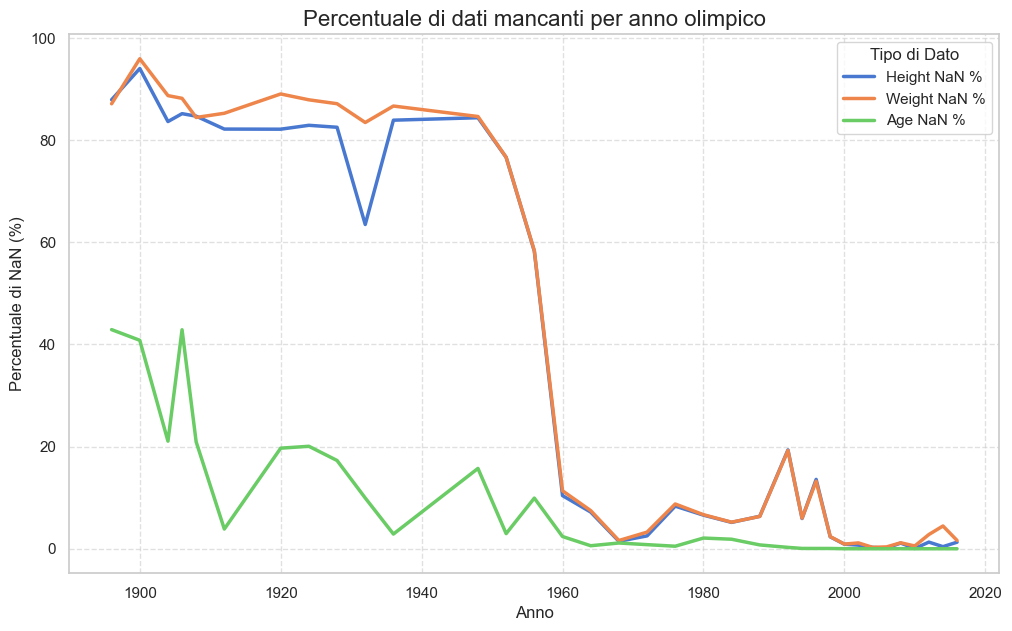

In [26]:
# Conta i NaN per ogni colonna
nan_count = df.isna().sum()

# Calcola la percentuale di NaN per ogni colonna
nan_percent = (df.isna().mean() * 100)

# Crea un DataFrame combinato con conteggio e percentuale
nan_summary = pd.DataFrame({
    'NaN Count': nan_count,
    'NaN %': nan_percent
}).sort_values(by='NaN Count', ascending=False)

# Stampa il risultato formattato
print(nan_summary.to_string(formatters={'NaN %': '{:.2f}%'.format}))

# Calcola la percentuale di NaN per ciascun anno
missing_by_year = (
    df.groupby('Year')[['Height', 'Weight', 'Age']]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index()
)

print(missing_by_year)


sns.set_theme(style="whitegrid", palette="muted") 


plt.figure(figsize=(12, 7)) 


plt.plot(missing_by_year['Year'], missing_by_year['Height'], 
         label='Height NaN %', 
         linewidth=2.5)      

plt.plot(missing_by_year['Year'], missing_by_year['Weight'], 
         label='Weight NaN %', 
         linewidth=2.5)      

plt.plot(missing_by_year['Year'], missing_by_year['Age'], 
         label='Age NaN %', 
         linewidth=2.5)      


plt.title('Percentuale di dati mancanti per anno olimpico', fontsize=16)
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Percentuale di NaN (%)', fontsize=12)
plt.legend(title='Tipo di Dato', fontsize=11) # Aggiungi un titolo alla legenda
plt.grid(True, linestyle='--', alpha=0.6) # Griglia più leggera

plt.show()

#reset dello stile
sns.reset_defaults()


Dall'analisi dei valori mancanti, è emerso che le feature fisiche (Height, Weight, Age) presentano una percentuale di NaN estremamente elevata (spesso >80%) prima del 1960, rendendo l'imputazione inaffidabile per quel periodo. Per preservare sia la completezza storica sia l'integrità dei dati fisici, si adotta il seguente approccio:

Dataset Filtrato (1960-oggi): Verrà utilizzato specificamente per le analisi (clustering/classificazione) che includono le feature fisiche, garantendo così una maggiore qualità e affidabilità dei dati di input.

**Dataset filtrato (1960 - 2016)**

In [27]:
# Creiamo il nuovo DataFrame per l'analisi "moderna"
df_moderno = df[df['Year'] >= 1960].copy()
print(df_moderno.describe())
df_moderno.isna().sum()

                  ID            Age         Height         Weight  \
count  209072.000000  207957.000000  197953.000000  197248.000000   
mean    68378.778516      24.966863     175.355145      70.667959   
std     39048.083180       5.485369      10.624469      14.446638   
min         1.000000      11.000000     127.000000      25.000000   
25%     34887.000000      21.000000     168.000000      60.000000   
50%     68360.000000      24.000000     175.000000      70.000000   
75%    102096.000000      28.000000     183.000000      79.000000   
max    135571.000000      71.000000     226.000000     214.000000   

                Year   Medal_Bronze     Medal_Gold     Medal_None  \
count  209072.000000  209072.000000  209072.000000  209072.000000   
mean     1991.858680       0.046348       0.045037       0.864162   
std        16.574837       0.210237       0.207386       0.342618   
min      1960.000000       0.000000       0.000000       0.000000   
25%      1980.000000       0.0000

ID                  0
Name                0
Sex                 0
Age              1115
Height          11119
Weight          11824
NOC                 0
Year                0
Season              0
City                0
Sport               0
Event               0
Medal_Bronze        0
Medal_Gold          0
Medal_None          0
Medal_Silver        0
dtype: int64

Imputazione dei valori NaN usando una mediana raggruppata. Per quanto riguarda peso e altezza si raggruppa per sesso e sport, mentre per l'età si raggruppa solo per lo sport, in modo da avere valori plausibili.

In [28]:
import os

# 1. Imputiamo Age usando la mediana dello Sport
df_moderno['Age'] = df_moderno.groupby('Sport')['Age'].transform(lambda x: x.fillna(x.median()))

# 2. Imputiamo Height e Weight usando la mediana di Sport e Sex
df_moderno['Height'] = df_moderno.groupby(['Sport', 'Sex'])['Height'].transform(lambda x: x.fillna(x.median()))
df_moderno['Weight'] = df_moderno.groupby(['Sport', 'Sex'])['Weight'].transform(lambda x: x.fillna(x.median()))

# 3. Pulizia finale (con il nuovo stile, senza inplace=True)
df_moderno['Age'] = df_moderno['Age'].fillna(df_moderno['Age'].median())
df_moderno['Height'] = df_moderno['Height'].fillna(df_moderno['Height'].median())
df_moderno['Weight'] = df_moderno['Weight'].fillna(df_moderno['Weight'].median())

print(df_moderno.describe())
print(df_moderno.isna().sum())

print("\nSalvataggio del DataFrame processato...")

output_dir = '../data/processed/'
file_name = 'athlete_events_processed.csv'
output_path = os.path.join(output_dir, file_name)

os.makedirs(output_dir, exist_ok=True)

df_moderno.to_csv(output_path, index=False)

print(f"\nSalvataggio completato!")
print(f"File salvato in: {output_path}")

                  ID            Age         Height         Weight  \
count  209072.000000  209072.000000  209072.000000  209072.000000   
mean    68378.778516      24.962204     175.369820      70.665197   
std     39048.083180       5.473868      10.472313      14.229842   
min         1.000000      11.000000     127.000000      25.000000   
25%     34887.000000      21.000000     168.000000      61.000000   
50%     68360.000000      24.000000     175.000000      70.000000   
75%    102096.000000      28.000000     182.000000      79.000000   
max    135571.000000      71.000000     226.000000     214.000000   

                Year   Medal_Bronze     Medal_Gold     Medal_None  \
count  209072.000000  209072.000000  209072.000000  209072.000000   
mean     1991.858680       0.046348       0.045037       0.864162   
std        16.574837       0.210237       0.207386       0.342618   
min      1960.000000       0.000000       0.000000       0.000000   
25%      1980.000000       0.0000

PermissionError: [Errno 13] Permission denied: '../data/processed/athlete_events_processed.csv'

**Grafici di analisi**

Grafico TOP atleti per numero di medaglie

C:\Users\matte\AppData\Local\Temp\ipykernel_26552\1763917468.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_fs, x='Total_Medals', y='Name', ax=axs[0, 0], palette='Reds_d')
C:\Users\matte\AppData\Local\Temp\ipykernel_26552\1763917468.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ms, x='Total_Medals', y='Name', ax=axs[0, 1], palette='Blues_d')
C:\Users\matte\AppData\Local\Temp\ipykernel_26552\1763917468.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_fw, x='Total_Medals', y='Name', ax=axs[1, 0], 

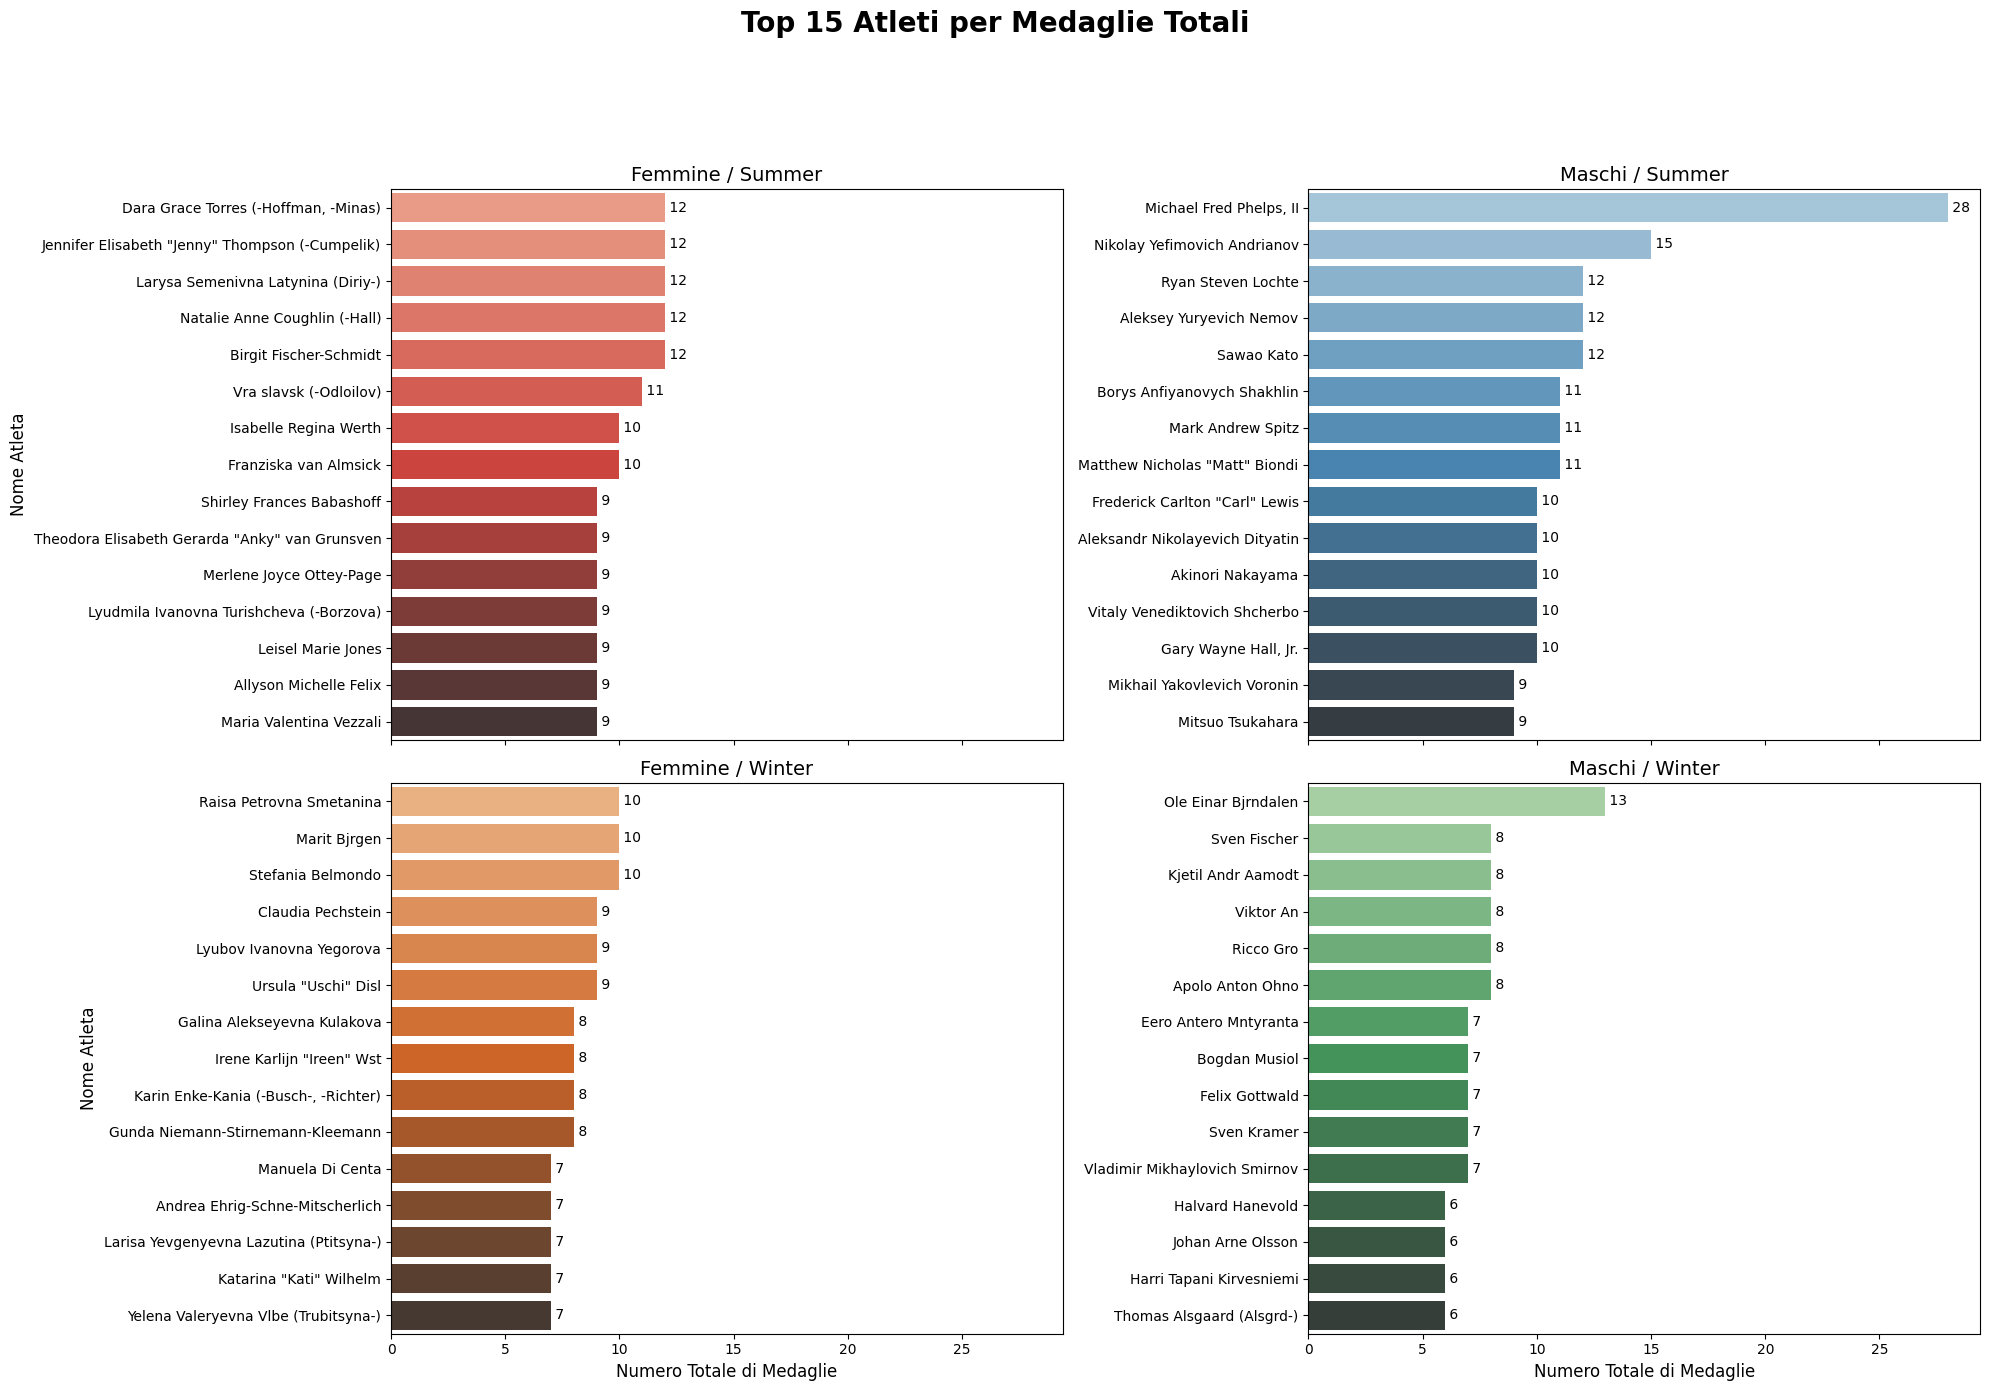

Grafico generato.


In [ ]:
athlete_medals = df_moderno.groupby(['ID', 'Name', 'Sex', 'Season']).agg(
    Gold=('Medal_Gold', 'sum'),
    Silver=('Medal_Silver', 'sum'),
    Bronze=('Medal_Bronze', 'sum')
).reset_index()

# Calcoliamo il totale delle medaglie per ogni atleta in quella stagione/sesso
athlete_medals['Total_Medals'] = athlete_medals['Gold'] + athlete_medals['Silver'] + athlete_medals['Bronze']

# Rimuoviamo chiunque non abbia vinto medaglie
athlete_medals = athlete_medals[athlete_medals['Total_Medals'] > 0]

# Imposta quanti atleti "top" vuoi vedere in ogni grafico
N = 15

# Ordiniamo e prendiamo i primi N da OGNI gruppo
top_athletes_per_group = athlete_medals.sort_values(
    by='Total_Medals', ascending=False
).groupby(['Sex', 'Season']).head(N).reset_index()


fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=True)

fig.suptitle(f'Top {N} Atleti per Medaglie Totali', 
             fontsize=20, weight='bold', y=1.02)




def add_value_labels(ax):
    """Aggiunge etichette di testo a un grafico a barre orizzontale."""
    for bar in ax.patches:
        # 'bar.get_width()' è il valore sull'asse X (totale medaglie)
        value = bar.get_width()
        
        # 'bar.get_y()' e 'bar.get_height()' ci danno la posizione Y
        y_pos = bar.get_y() + bar.get_height() / 2
        
        # Aggiungiamo il testo
        ax.text(
            value,           # Posizione X (alla fine della barra)
            y_pos,           # Posizione Y (al centro della barra)
            f' {int(value)}',  # Il testo (come numero intero, con uno spazio)
            va='center',     # Allineamento verticale
            ha='left'        # Allineamento orizzontale
        )



data_fs = top_athletes_per_group.query("Sex == 'F' and Season == 'Summer'")
data_ms = top_athletes_per_group.query("Sex == 'M' and Season == 'Summer'")
data_fw = top_athletes_per_group.query("Sex == 'F' and Season == 'Winter'")
data_mw = top_athletes_per_group.query("Sex == 'M' and Season == 'Winter'")


sns.barplot(data=data_fs, x='Total_Medals', y='Name', ax=axs[0, 0], palette='Reds_d')
axs[0, 0].set_title('Femmine / Summer', fontsize=14)
axs[0, 0].set_ylabel('Nome Atleta', fontsize=12) # Etichetta Y solo a sinistra
axs[0, 0].set_xlabel('') # Nascondiamo l'etichetta X
add_value_labels(axs[0, 0])

sns.barplot(data=data_ms, x='Total_Medals', y='Name', ax=axs[0, 1], palette='Blues_d')
axs[0, 1].set_title('Maschi / Summer', fontsize=14)
axs[0, 1].set_ylabel('') # Nascondiamo l'etichetta Y
axs[0, 1].set_xlabel('') # Nascondiamo l'etichetta X
add_value_labels(axs[0, 1])


sns.barplot(data=data_fw, x='Total_Medals', y='Name', ax=axs[1, 0], palette='Oranges_d')
axs[1, 0].set_title('Femmine / Winter', fontsize=14)
axs[1, 0].set_ylabel('Nome Atleta', fontsize=12)
axs[1, 0].set_xlabel('Numero Totale di Medaglie', fontsize=12) # Etichetta X solo in basso
add_value_labels(axs[1, 0])


sns.barplot(data=data_mw, x='Total_Medals', y='Name', ax=axs[1, 1], palette='Greens_d')
axs[1, 1].set_title('Maschi / Winter', fontsize=14)
axs[1, 1].set_ylabel('')
axs[1, 1].set_xlabel('Numero Totale di Medaglie', fontsize=12)
add_value_labels(axs[1, 1])


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 'rect' lascia spazio per il suptitle
plt.show()

print("Grafico generato.")

Medagliere delle nazioni dividendo tra Olimpiadi estive ed invernali

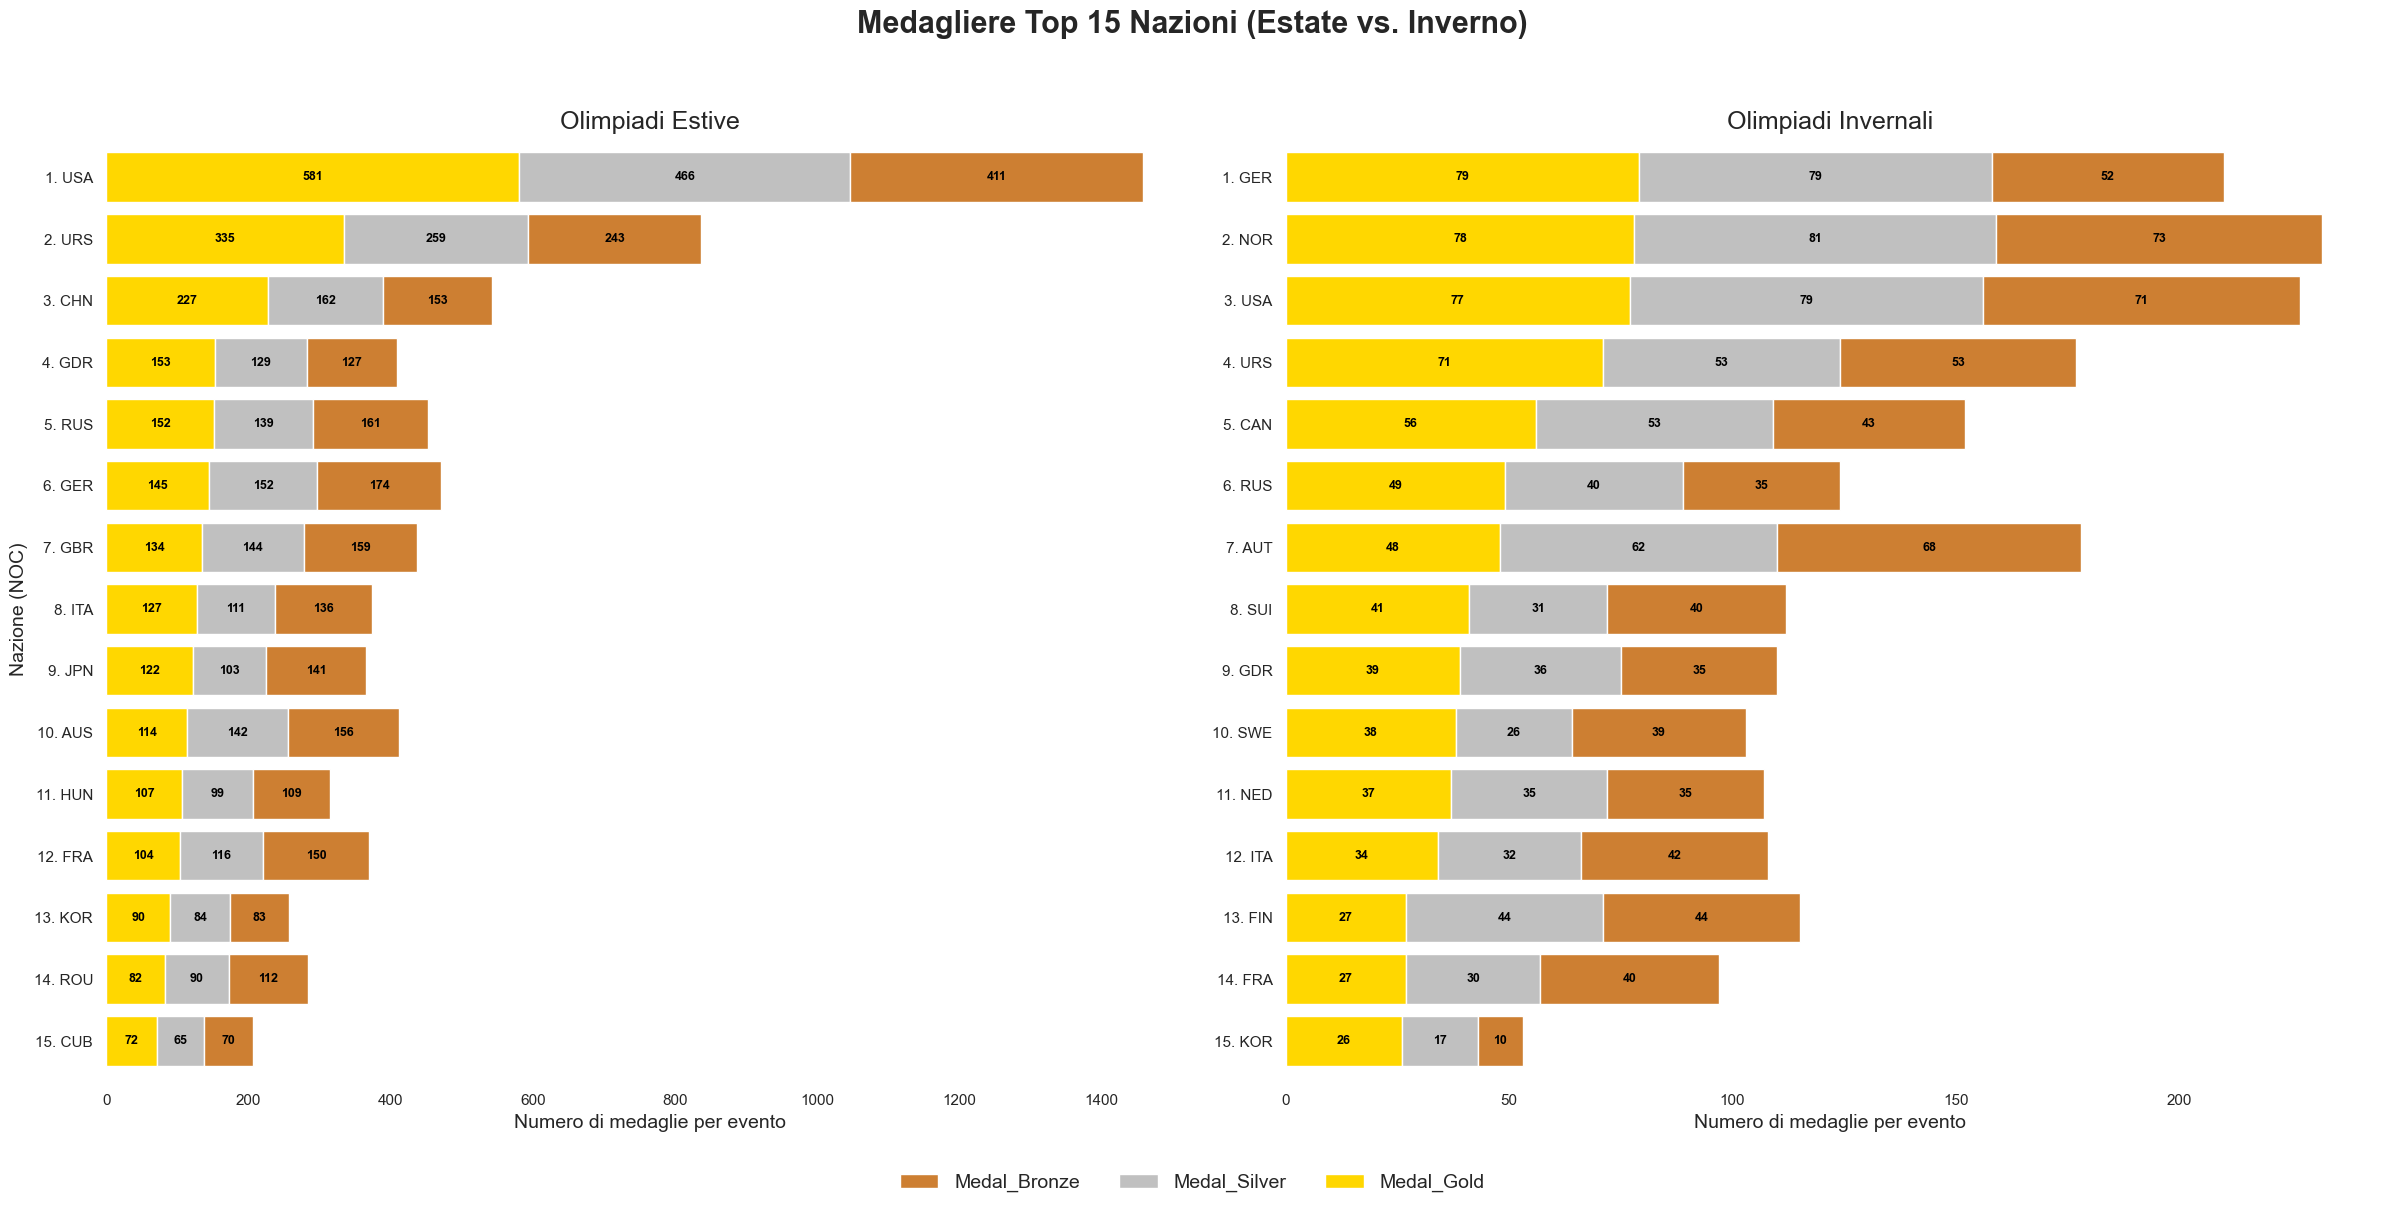

In [ ]:
#PROBLEMA: gestione degli sport di squadra perchè nel dataset per uno sport di squadra conta più di una medaglia e non va bene
#risolto facendo un raggruppamento per eventi e facendo max

sns.set_theme(style="white", palette="muted")


event_medals = df_moderno.groupby(['Year', 'Season', 'Event', 'NOC'])[['Medal_Gold', 'Medal_Silver', 'Medal_Bronze']].max()


medagliere_corretto = event_medals.groupby(['NOC', 'Season']).sum().reset_index()


medagliere_corretto = medagliere_corretto[
    (medagliere_corretto['Medal_Gold'] > 0) | 
    (medagliere_corretto['Medal_Silver'] > 0) | 
    (medagliere_corretto['Medal_Bronze'] > 0)
]


medagliere_sorted = medagliere_corretto.sort_values(
    by=['Medal_Gold', 'Medal_Silver', 'Medal_Bronze'], 
    ascending=[False, False, False]
)


N = 15 

top_summer_df = medagliere_sorted[medagliere_sorted['Season'] == 'Summer'].head(N).copy()
top_winter_df = medagliere_sorted[medagliere_sorted['Season'] == 'Winter'].head(N).copy()

for df in [top_summer_df, top_winter_df]:
    df['Rank'] = range(1, len(df) + 1)
    df['Rank_Label'] = df['Rank'].astype(str) + '. ' + df['NOC'] # Es: "1. USA"


top_summer_plot = top_summer_df.set_index('Rank_Label')[['Medal_Gold', 'Medal_Silver', 'Medal_Bronze']]
top_winter_plot = top_winter_df.set_index('Rank_Label')[['Medal_Gold', 'Medal_Silver', 'Medal_Bronze']]


top_summer_plot = top_summer_plot.iloc[::-1]
top_winter_plot = top_winter_plot.iloc[::-1]

medal_colors = ['gold', 'silver', '#cd7f32'] 

fig, axs = plt.subplots(1, 2, figsize=(24, 12))
fig.suptitle(f'Medagliere Top {N} Nazioni (Estate vs. Inverno)', fontsize=22, weight='bold')

top_summer_plot.plot(
    kind='barh', stacked=True, color=medal_colors, ax=axs[0], width=0.8
)
axs[0].set_title('Olimpiadi Estive', fontsize=18)
axs[0].set_xlabel('Numero di medaglie per evento', fontsize=14)
axs[0].set_ylabel('Nazione (NOC)', fontsize=14)
axs[0].legend_.remove()


top_winter_plot.plot(
    kind='barh', stacked=True, color=medal_colors, ax=axs[1], width=0.8
)
axs[1].set_title('Olimpiadi Invernali', fontsize=18)
axs[1].set_xlabel('Numero di medaglie per evento', fontsize=14)
axs[1].set_ylabel('')
axs[1].legend_.remove()

for ax in axs:
    for container in ax.containers:
        labels = [int(val) if val > 0 else '' for val in container.datavalues]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center', 
            color='black',       
            weight='bold',
            fontsize=9
        )
        
sns.despine(left=True, bottom=True, trim=True)

handles, labels = axs[1].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], 
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=3,
           fontsize=14,
           frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Mappa coropletica delle nazioni

C:\Users\matte\AppData\Local\Temp\ipykernel_26552\1552008906.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medagliere_estate['iso_a3'] = medagliere_estate['NOC'].apply(map_noc_to_iso)
C:\Users\matte\AppData\Local\Temp\ipykernel_26552\1552008906.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medagliere_inverno['iso_a3'] = medagliere_inverno['NOC'].apply(map_noc_to_iso)


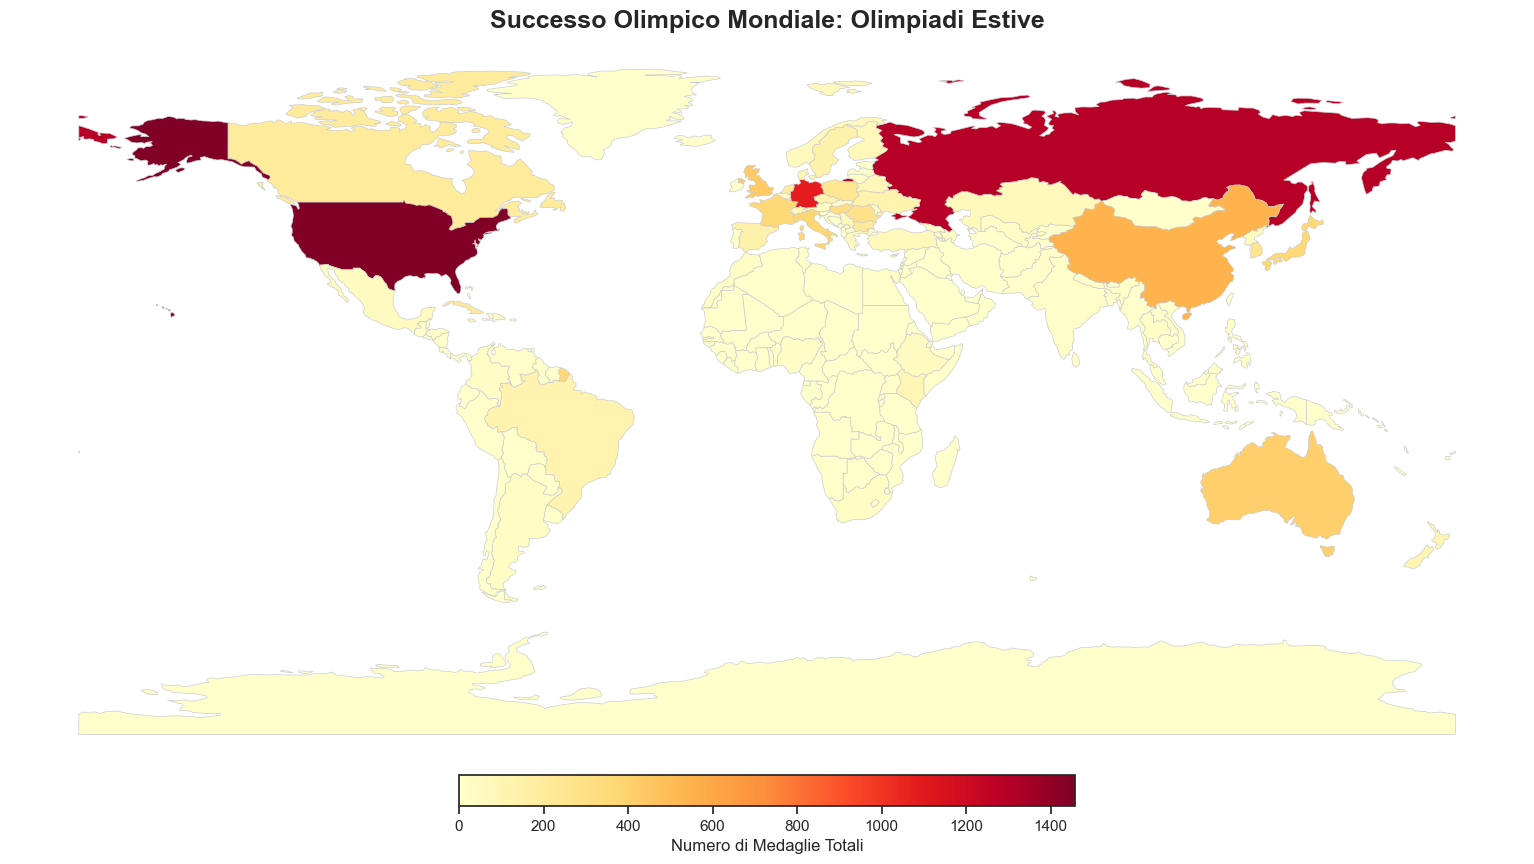

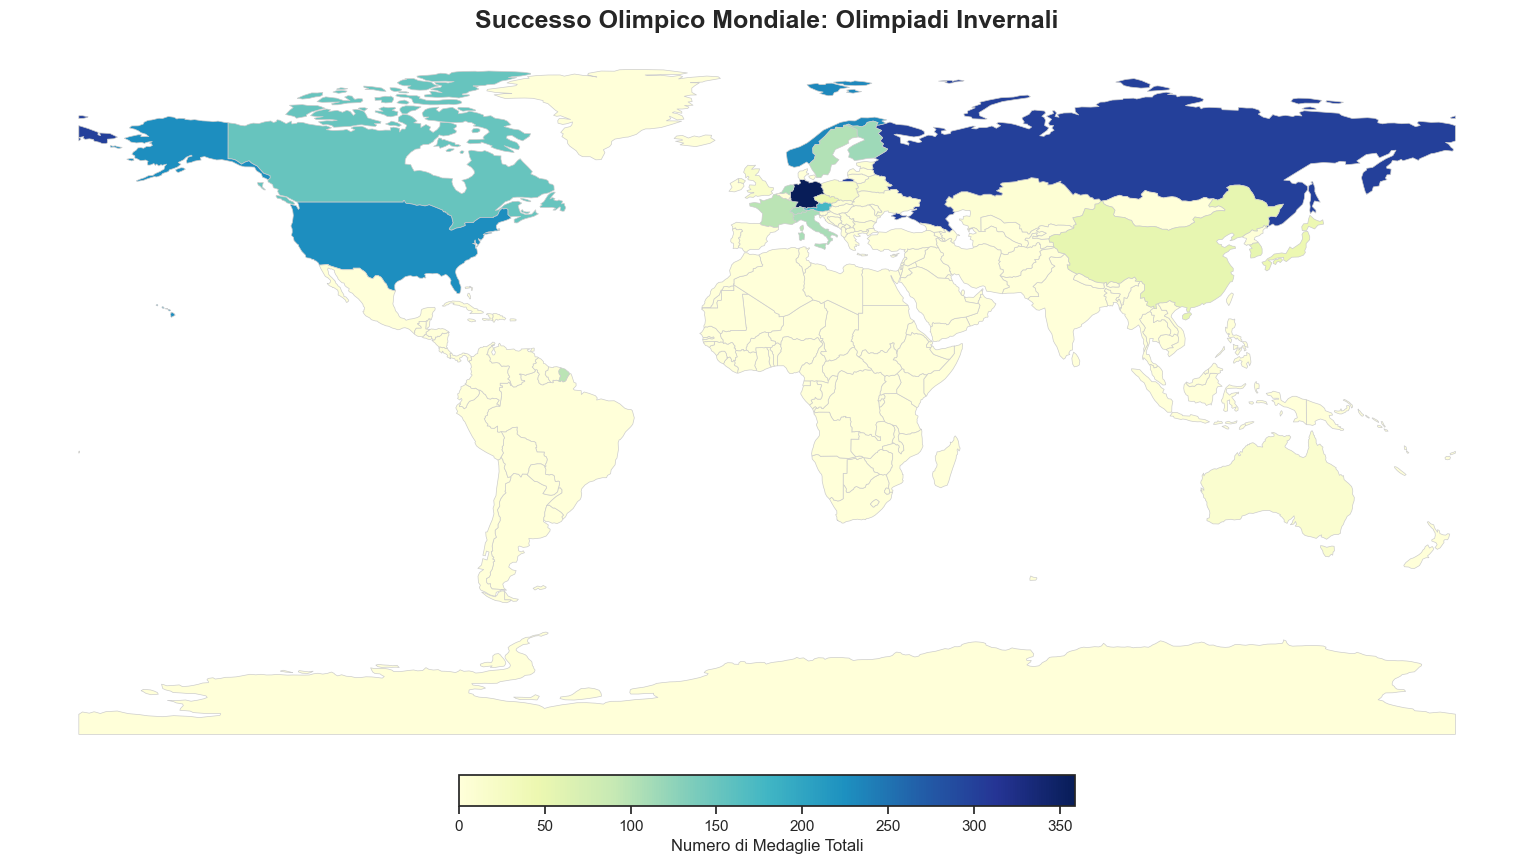

In [ ]:
import geopandas

sns.set_theme(style="white")

event_medals = df_moderno.groupby(['Year', 'Season', 'Event', 'NOC'])[['Medal_Gold', 'Medal_Silver', 'Medal_Bronze']].max()
medagliere_corretto = event_medals.groupby(['NOC', 'Season']).sum().reset_index()

medagliere_corretto.rename(columns={
    'Medal_Gold': 'Gold',
    'Medal_Silver': 'Silver',
    'Medal_Bronze': 'Bronze'
}, inplace=True)

medagliere_corretto['Total'] = medagliere_corretto['Gold'] + medagliere_corretto['Silver'] + medagliere_corretto['Bronze']


medagliere_estate = medagliere_corretto[medagliere_corretto['Season'] == 'Summer']
medagliere_inverno = medagliere_corretto[medagliere_corretto['Season'] == 'Winter']

noc_to_iso_map = {
    'GER': 'DEU', 'FRG': 'DEU', 'GDR': 'DEU', 
    'URS': 'RUS', 'TCH': 'CZE', 'YUG': 'SRB', 'SUI': 'CHE', 
    'NED': 'NLD', 'DEN': 'DNK', 'GRE': 'GRC', 'POR': 'PRT', 
    'RSA': 'ZAF', 'NGR': 'NGA', 'NZL': 'NZL', 'JAM': 'JAM', 
    'CUB': 'CUB', 'AUT': 'AUT', 'ROU': 'ROU', 'BUL': 'BGR', 
}

path_to_map = "../data/map/ne_110m_admin_0_countries.shp"
world = geopandas.read_file(path_to_map)
NOME_COLONNA_ISO = 'ADM0_A3' 
all_iso_codes = set(world[NOME_COLONNA_ISO])

def map_noc_to_iso(noc):
    if noc in noc_to_iso_map:
        return noc_to_iso_map[noc]
    if noc in all_iso_codes: 
        return noc
    return None 

medagliere_estate['iso_a3'] = medagliere_estate['NOC'].apply(map_noc_to_iso)
medagliere_inverno['iso_a3'] = medagliere_inverno['NOC'].apply(map_noc_to_iso)

mappa_estate = medagliere_estate.groupby('iso_a3')[['Total']].sum().reset_index()
mappa_inverno = medagliere_inverno.groupby('iso_a3')[['Total']].sum().reset_index()

world_merged_estate = world.merge(mappa_estate, left_on=NOME_COLONNA_ISO, right_on='iso_a3', how='left')
world_merged_inverno = world.merge(mappa_inverno, left_on=NOME_COLONNA_ISO, right_on='iso_a3', how='left')

world_merged_estate['Total'] = world_merged_estate['Total'].fillna(0)
world_merged_inverno['Total'] = world_merged_inverno['Total'].fillna(0)

fig_estate, ax_estate = plt.subplots(1, 1, figsize=(20, 10))

world_merged_estate.plot(
    column='Total',     
    cmap='YlOrRd',       
    ax=ax_estate,
    edgecolor='0.8',   
    linewidth=0.5,
    legend=True,       
    legend_kwds={
        'label': "Numero di Medaglie Totali",
        'orientation': "horizontal",
        'shrink': 0.5,  
        'fraction': 0.04,
        'pad': 0.01     
    },
    missing_kwds={"color": "lightgrey"}
)
ax_estate.axis('off')
ax_estate.set_title('Successo Olimpico Mondiale: Olimpiadi Estive', fontsize=18, weight='bold')


plt.show()


fig_inverno, ax_inverno = plt.subplots(1, 1, figsize=(20, 10))

world_merged_inverno.plot(
    column='Total',     
    cmap='YlGnBu',     
    ax=ax_inverno,
    edgecolor='0.8',   
    linewidth=0.5,
    legend=True,       
    legend_kwds={
        'label': "Numero di Medaglie Totali",
        'orientation': "horizontal",
        'shrink': 0.5,  
        'fraction': 0.04,
        'pad': 0.01     
    },
    missing_kwds={"color": "lightgrey"}
)
ax_inverno.axis('off')
ax_inverno.set_title('Successo Olimpico Mondiale: Olimpiadi Invernali', fontsize=18, weight='bold')


plt.show()



Evoluzione partecipazione Maschi e Femmine ai giochi estivi

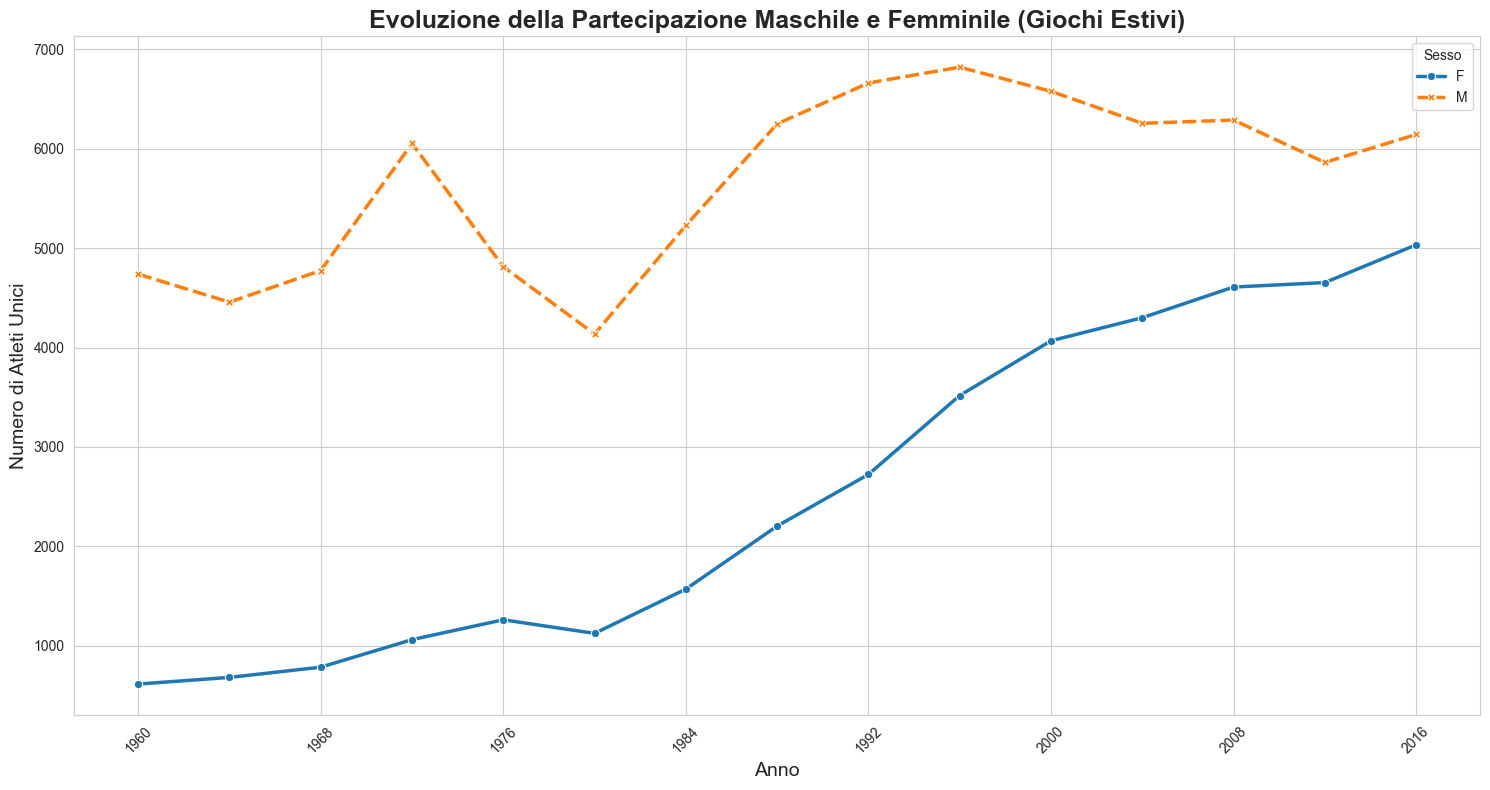

In [ ]:
summer_df = df_moderno[df_moderno['Season'] == 'Summer']

# Troviamo gli atleti unici per ogni anno
# (un atleta conta 1 volta per edizione, anche se fa 8 eventi)
unique_athletes_per_year = summer_df.drop_duplicates(subset=['Year', 'ID'])

# Raggruppiamo per Anno e Sesso e contiamo
evolution_data = unique_athletes_per_year.groupby(['Year', 'Sex'])['ID'].count().reset_index()

# Rinominiamo la colonna del conteggio per chiarezza
evolution_data.rename(columns={'ID': 'Numero di Atleti'}, inplace=True)


# --- 2. Creazione del Grafico ---

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Creiamo il grafico a linee
line_plot = sns.lineplot(
    data=evolution_data, 
    x='Year', 
    y='Numero di Atleti', 
    hue='Sex',  # 'hue' usa la colonna 'Sex' per creare linee di colori diversi
    style='Sex', # 'style' usa marcatori diversi
    markers=True,
    lw=2.5 # Spessore della linea
)

# --- 3. Abbellimento ---
plt.title('Evoluzione della Partecipazione Maschile e Femminile (Giochi Estivi)', fontsize=18, weight='bold')
plt.xlabel('Anno', fontsize=14)
plt.ylabel('Numero di Atleti Unici', fontsize=14)
plt.legend(title='Sesso')

# Assicuriamoci che gli anni sull'asse X siano leggibili
plt.xticks(rotation=45, ticks=sorted(evolution_data['Year'].unique())[::2]) # Mostra un anno ogni due

plt.tight_layout()
plt.show()

Evoluzione partecipazione Maschi e Femmine ai giochi invernali

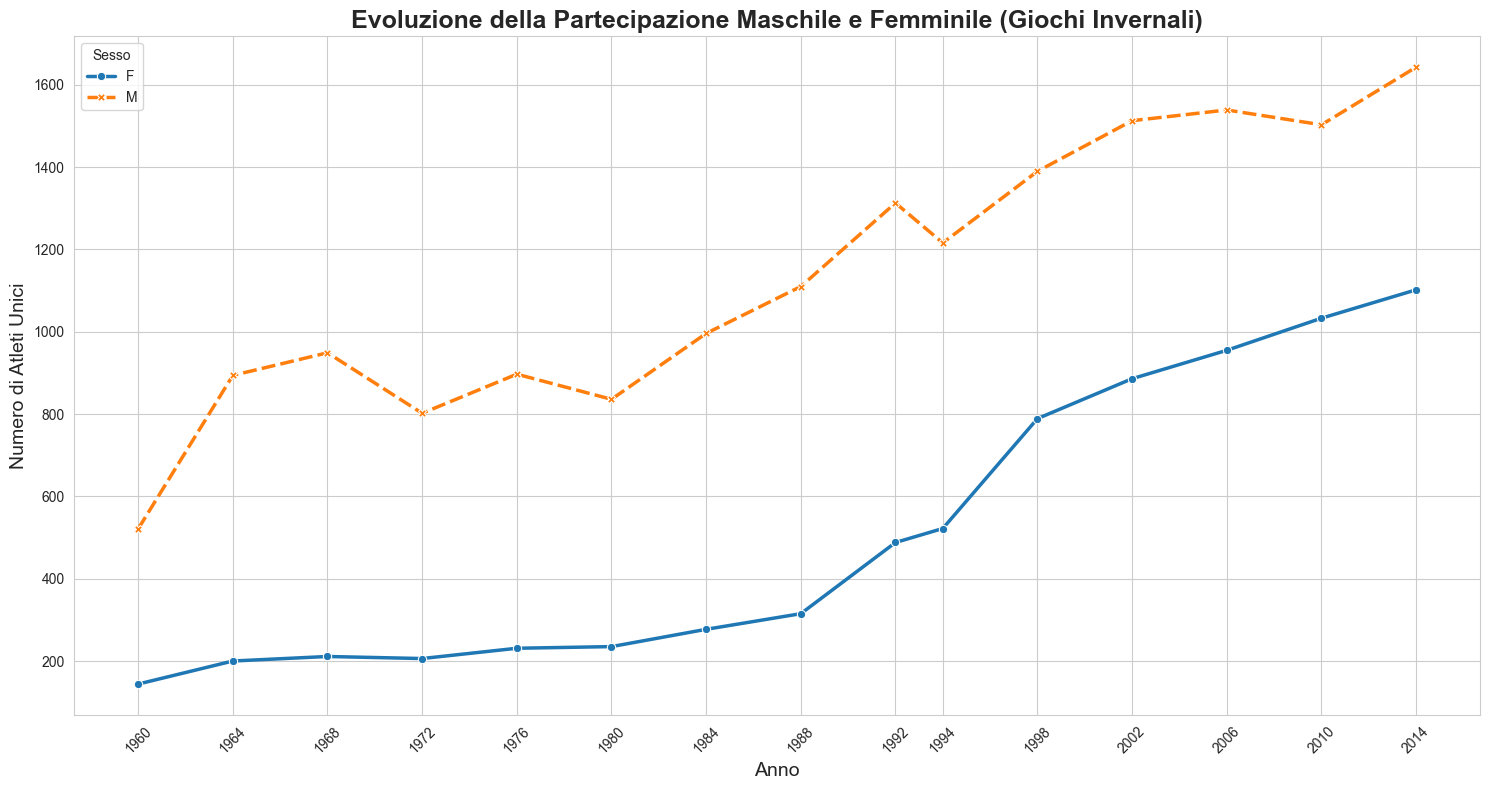

In [ ]:
# Filtriamo solo per i Giochi Invernali
winter_df = df_moderno[df_moderno['Season'] == 'Winter']

# Troviamo gli atleti unici per ogni anno
# (un atleta conta 1 volta per edizione)
unique_athletes_per_year_winter = winter_df.drop_duplicates(subset=['Year', 'ID'])

# Raggruppiamo per Anno e Sesso e contiamo
evolution_data_winter = unique_athletes_per_year_winter.groupby(['Year', 'Sex'])['ID'].count().reset_index()

# Rinominiamo la colonna del conteggio per chiarezza
evolution_data_winter.rename(columns={'ID': 'Numero di Atleti'}, inplace=True)


# --- 2. Creazione del Grafico ---

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Creiamo il grafico a linee
line_plot_winter = sns.lineplot(
    data=evolution_data_winter, 
    x='Year', 
    y='Numero di Atleti', 
    hue='Sex',  # Colori diversi per 'Sex'
    style='Sex', # Marcatori diversi per 'Sex'
    markers=True,
    lw=2.5
)

# --- 3. Abbellimento ---
plt.title('Evoluzione della Partecipazione Maschile e Femminile (Giochi Invernali)', fontsize=18, weight='bold')
plt.xlabel('Anno', fontsize=14)
plt.ylabel('Numero di Atleti Unici', fontsize=14)
plt.legend(title='Sesso')

# Assicuriamoci che gli anni sull'asse X siano leggibili
# I giochi invernali sono meno, quindi possiamo mostrarli più di frequente
plt.xticks(rotation=45, ticks=sorted(evolution_data_winter['Year'].unique())[::1]) # Mostra tutti gli anni

plt.tight_layout()
plt.show()

Media Altezza e Peso (Top 5 e Bottom 5)

Calcolate medie per 51 sport con più di 20 atleti.


C:\Users\matte\AppData\Local\Temp\ipykernel_7528\316249780.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  h_plot = sns.barplot(
C:\Users\matte\AppData\Local\Temp\ipykernel_7528\316249780.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  w_plot = sns.barplot(


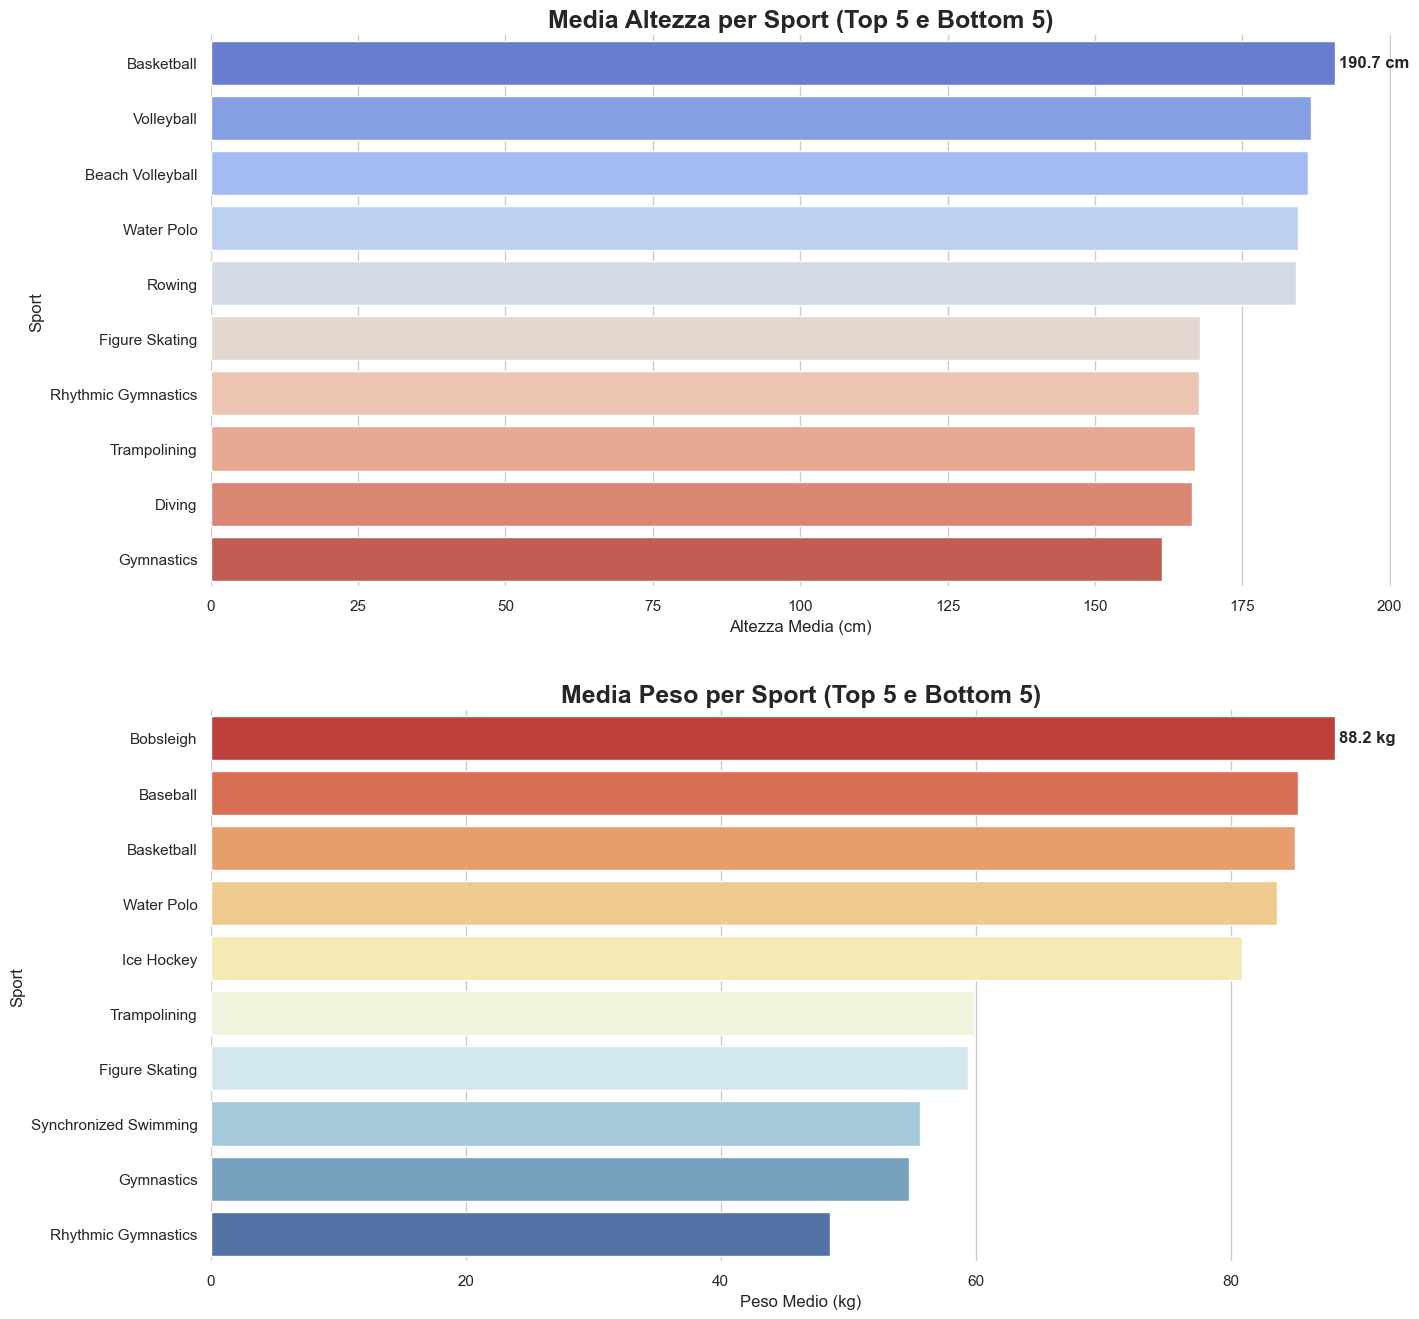

In [ ]:
df_atleti_unici_sport = df_moderno.drop_duplicates(subset=['ID', 'Sport'])

# --- 3. Calcolo Medie e Filtro ---

# Calcoliamo la media E il numero di atleti UNICI per sport
sport_stats = df_atleti_unici_sport.groupby('Sport').agg(
    Avg_Height=('Height', 'mean'),
    Avg_Weight=('Weight', 'mean'),
    Count=('ID', 'nunique') # 'nunique' è più sicuro
).reset_index()

# FILTRO: Teniamo solo sport con un numero decente di atleti unici
MIN_ATHLETES = 20 
sport_stats_filtrato = sport_stats[sport_stats['Count'] > MIN_ATHLETES]
print(f"Calcolate medie per {len(sport_stats_filtrato)} sport con più di {MIN_ATHLETES} atleti.")

# --- 4. Dati per i Grafici (Top/Bottom 5) ---

# Altezza
height_sorted = sport_stats_filtrato.sort_values(by='Avg_Height', ascending=False)
top_5_height = height_sorted.head(5)
bottom_5_height = height_sorted.tail(5)
height_plot_df = pd.concat([top_5_height, bottom_5_height]).sort_values(by='Avg_Height', ascending=False)

# Peso
weight_sorted = sport_stats_filtrato.sort_values(by='Avg_Weight', ascending=False)
top_5_weight = weight_sorted.head(5)
bottom_5_weight = weight_sorted.tail(5)
weight_plot_df = pd.concat([top_5_weight, bottom_5_weight]).sort_values(by='Avg_Weight', ascending=False)


# --- 5. Creazione dei Grafici ---
sns.set_theme(style="whitegrid", palette="muted")
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(15, 14)) # Due grafici uno sopra l'altro

# Grafico Altezza
h_plot = sns.barplot(
    data=height_plot_df,
    x='Avg_Height',
    y='Sport',
    ax=axs[0],
    palette='coolwarm'
)
axs[0].set_title('Media Altezza per Sport (Top 5 e Bottom 5)', fontsize=18, weight='bold')
axs[0].set_xlabel('Altezza Media (cm)', fontsize=12)
axs[0].set_ylabel('Sport', fontsize=12)
# Aggiungi etichette
axs[0].bar_label(h_plot.containers[0], fmt='%.1f cm', padding=3, weight='bold')


# Grafico Peso
w_plot = sns.barplot(
    data=weight_plot_df,
    x='Avg_Weight',
    y='Sport',
    ax=axs[1],
    palette='RdYlBu'
)
axs[1].set_title('Media Peso per Sport (Top 5 e Bottom 5)', fontsize=18, weight='bold')
axs[1].set_xlabel('Peso Medio (kg)', fontsize=12)
axs[1].set_ylabel('Sport', fontsize=12)
# Aggiungi etichette
axs[1].bar_label(w_plot.containers[0], fmt='%.1f kg', padding=3, weight='bold')


plt.tight_layout(pad=3.0) # Aggiunge spazio tra i due grafici
sns.despine(left=True, bottom=True)
plt.show()

Media età per sport (Top 5 e Bottom 5)

Calcolate medie per 51 sport con più di 20 atleti.


C:\Users\matte\AppData\Local\Temp\ipykernel_7528\3832142005.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  age_plot = sns.barplot(


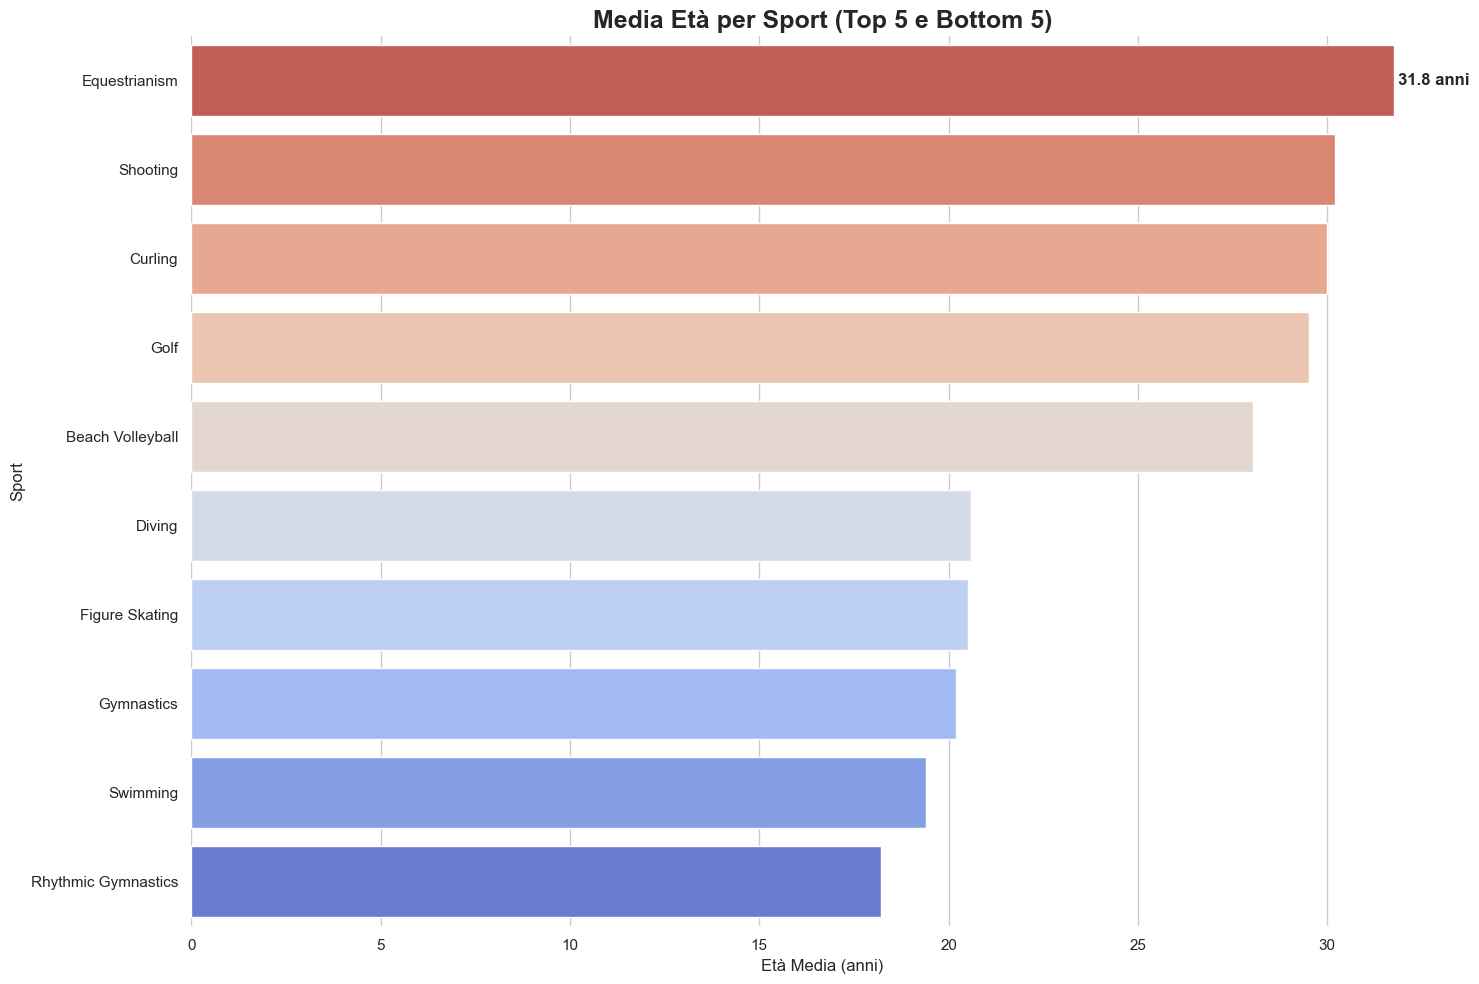

In [ ]:
df_atleti_unici_sport = df_moderno.drop_duplicates(subset=['ID', 'Sport'])

# --- 3. Calcolo Medie e Filtro ---

# Calcoliamo la media E il numero di atleti UNICI per sport
sport_stats = df_atleti_unici_sport.groupby('Sport').agg(
    Avg_Age=('Age', 'mean'),
    Count=('ID', 'nunique') # 'nunique' è più sicuro
).reset_index()

# FILTRO: Teniamo solo sport con un numero decente di atleti unici
MIN_ATHLETES = 20 
sport_stats_filtrato = sport_stats[sport_stats['Count'] > MIN_ATHLETES]
print(f"Calcolate medie per {len(sport_stats_filtrato)} sport con più di {MIN_ATHLETES} atleti.")

# --- 4. Dati per il Grafico (Top/Bottom 5) ---

# Età
age_sorted = sport_stats_filtrato.sort_values(by='Avg_Age', ascending=False)
top_5_age = age_sorted.head(5)
bottom_5_age = age_sorted.tail(5)

# Uniamo i due dataframe per un unico plot
age_plot_df = pd.concat([top_5_age, bottom_5_age]).sort_values(by='Avg_Age', ascending=False)


# --- 5. Creazione del Grafico ---
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(15, 10)) # Un solo grafico, più alto

# Creiamo un palette divergente: rosso per i più "anziani", blu per i più "giovani"
palette = sns.color_palette("coolwarm_r", n_colors=10)

# Grafico Età
age_plot = sns.barplot(
    data=age_plot_df,
    x='Avg_Age',
    y='Sport',
    palette=palette # Applica la palette
)
age_plot.set_title('Media Età per Sport (Top 5 e Bottom 5)', fontsize=18, weight='bold')
age_plot.set_xlabel('Età Media (anni)', fontsize=12)
age_plot.set_ylabel('Sport', fontsize=12)

# Aggiungi etichette
age_plot.bar_label(age_plot.containers[0], fmt='%.1f anni', padding=3, weight='bold')

plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.show()

Lo stesso diviso per maschi e femmine

Calcolate medie per Uomini (48 sport) e Donne (49 sport).
Dati Top/Bottom 5 pronti per il plot.


C:\Users\matte\AppData\Local\Temp\ipykernel_25540\1115555776.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  h_plot_m = sns.barplot(data=height_male_plot, x='Avg_Height', y='Sport', ax=axs[0, 0], palette='coolwarm_r')
C:\Users\matte\AppData\Local\Temp\ipykernel_25540\1115555776.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  h_plot_f = sns.barplot(data=height_female_plot, x='Avg_Height', y='Sport', ax=axs[0, 1], palette='coolwarm_r')
C:\Users\matte\AppData\Local\Temp\ipykernel_25540\1115555776.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  w_plot_m = sns.barplo

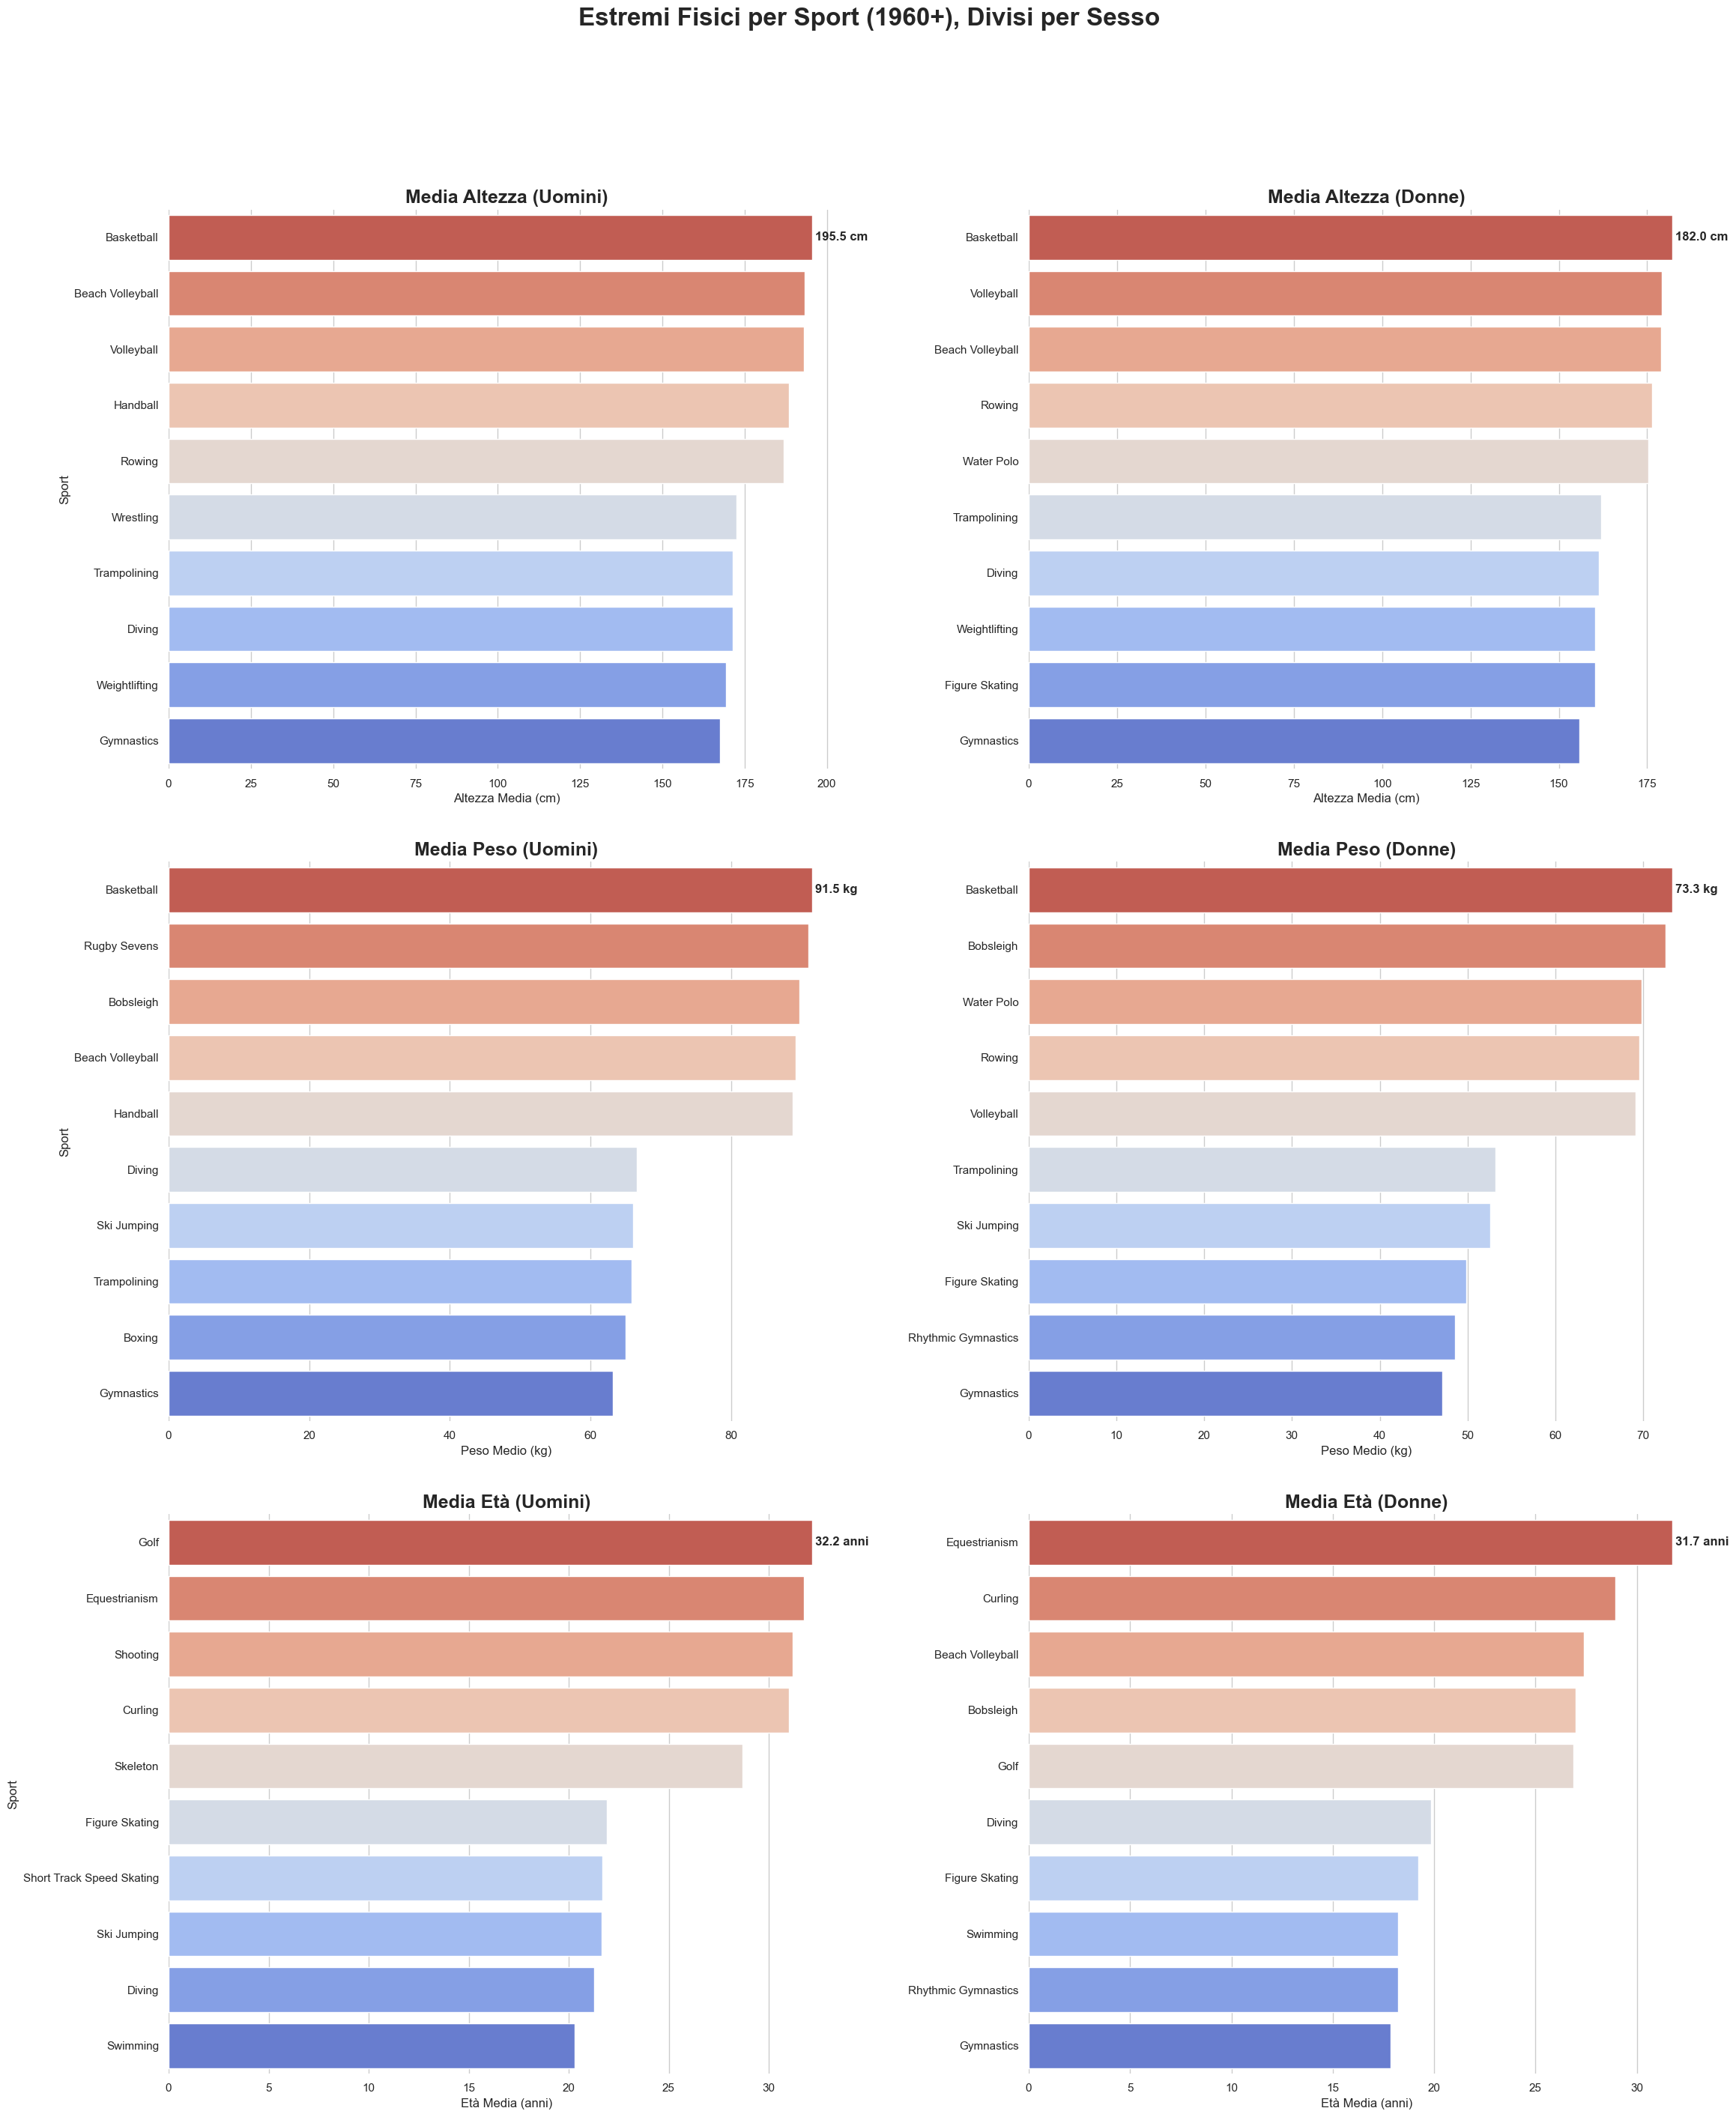

In [31]:
df_atleti_unici_sport = df_moderno.drop_duplicates(subset=['ID', 'Sport'])

# SEPARAZIONE: Creiamo due dataframe, uno per Uomini (M) e uno per Donne (F)
male_df = df_atleti_unici_sport[df_atleti_unici_sport['Sex'] == 'M']
female_df = df_atleti_unici_sport[df_atleti_unici_sport['Sex'] == 'F']

# --- 3. Calcolo Medie e Filtro (separati) ---

MIN_ATHLETES = 20 # Filtro per medie affidabili

def get_sport_stats(df, min_athletes=MIN_ATHLETES):
    """Funzione helper per calcolare le medie per sport."""
    stats = df.groupby('Sport').agg(
        Avg_Height=('Height', 'mean'),
        Avg_Weight=('Weight', 'mean'),
        Avg_Age=('Age', 'mean'),
        Count=('ID', 'nunique')
    ).reset_index()
    # Applica filtro e ritorna
    return stats[stats['Count'] > min_athletes]

# Calcoliamo le statistiche per Uomini e Donne
male_stats = get_sport_stats(male_df)
female_stats = get_sport_stats(female_df)
print(f"Calcolate medie per Uomini ({len(male_stats)} sport) e Donne ({len(female_stats)} sport).")

# --- 4. Dati per i Grafici (Top/Bottom 5 per 6 categorie) ---

def get_plot_data(df, metric_col):
    """Funzione helper per prendere i Top/Bottom 5."""
    sorted_df = df.sort_values(by=metric_col, ascending=False)
    top_5 = sorted_df.head(5)
    bottom_5 = sorted_df.tail(5)
    return pd.concat([top_5, bottom_5]).sort_values(by=metric_col, ascending=False)

# Altezza
height_male_plot = get_plot_data(male_stats, 'Avg_Height')
height_female_plot = get_plot_data(female_stats, 'Avg_Height')

# Peso
weight_male_plot = get_plot_data(male_stats, 'Avg_Weight')
weight_female_plot = get_plot_data(female_stats, 'Avg_Weight')

# Età
age_male_plot = get_plot_data(male_stats, 'Avg_Age')
age_female_plot = get_plot_data(female_stats, 'Avg_Age')
print("Dati Top/Bottom 5 pronti per il plot.")

# --- 5. Creazione dei Grafici (Griglia 3x2) ---
sns.set_theme(style="whitegrid", palette="muted")
# 3 righe, 2 colonne. Aumentiamo 'figsize' per contenere tutto.
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(24, 28))

# Impostiamo un titolo generale per l'intera figura
fig.suptitle('Estremi Fisici per Sport (1960+), Divisi per Sesso', fontsize=24, weight='bold', y=1.02)

# --- Riga 1: ALTEZZA ---
h_plot_m = sns.barplot(data=height_male_plot, x='Avg_Height', y='Sport', ax=axs[0, 0], palette='coolwarm_r')
h_plot_m.set_title('Media Altezza (Uomini)', fontsize=18, weight='bold')
h_plot_m.set_xlabel('Altezza Media (cm)', fontsize=12)
h_plot_m.set_ylabel('Sport', fontsize=12)
h_plot_m.bar_label(h_plot_m.containers[0], fmt='%.1f cm', padding=3, weight='bold')

h_plot_f = sns.barplot(data=height_female_plot, x='Avg_Height', y='Sport', ax=axs[0, 1], palette='coolwarm_r')
h_plot_f.set_title('Media Altezza (Donne)', fontsize=18, weight='bold')
h_plot_f.set_xlabel('Altezza Media (cm)', fontsize=12)
h_plot_f.set_ylabel('') # Rimuoviamo l'etichetta Y per pulizia
h_plot_f.bar_label(h_plot_f.containers[0], fmt='%.1f cm', padding=3, weight='bold')

# --- Riga 2: PESO ---
w_plot_m = sns.barplot(data=weight_male_plot, x='Avg_Weight', y='Sport', ax=axs[1, 0], palette='coolwarm_r')
w_plot_m.set_title('Media Peso (Uomini)', fontsize=18, weight='bold')
w_plot_m.set_xlabel('Peso Medio (kg)', fontsize=12)
w_plot_m.set_ylabel('Sport', fontsize=12)
w_plot_m.bar_label(w_plot_m.containers[0], fmt='%.1f kg', padding=3, weight='bold')

w_plot_f = sns.barplot(data=weight_female_plot, x='Avg_Weight', y='Sport', ax=axs[1, 1], palette='coolwarm_r')
w_plot_f.set_title('Media Peso (Donne)', fontsize=18, weight='bold')
w_plot_f.set_xlabel('Peso Medio (kg)', fontsize=12)
w_plot_f.set_ylabel('')
w_plot_f.bar_label(w_plot_f.containers[0], fmt='%.1f kg', padding=3, weight='bold')

# --- Riga 3: ETÀ ---
a_plot_m = sns.barplot(data=age_male_plot, x='Avg_Age', y='Sport', ax=axs[2, 0], palette='coolwarm_r')
a_plot_m.set_title('Media Età (Uomini)', fontsize=18, weight='bold')
a_plot_m.set_xlabel('Età Media (anni)', fontsize=12)
a_plot_m.set_ylabel('Sport', fontsize=12)
a_plot_m.bar_label(a_plot_m.containers[0], fmt='%.1f anni', padding=3, weight='bold')

a_plot_f = sns.barplot(data=age_female_plot, x='Avg_Age', y='Sport', ax=axs[2, 1], palette='coolwarm_r')
a_plot_f.set_title('Media Età (Donne)', fontsize=18, weight='bold')
a_plot_f.set_xlabel('Età Media (anni)', fontsize=12)
a_plot_f.set_ylabel('')
a_plot_f.bar_label(a_plot_f.containers[0], fmt='%.1f anni', padding=3, weight='bold')


# --- Finitura ---
plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.98]) # Aggiusta per il suptitle
sns.despine(left=True, bottom=True)
plt.show()

Top 15 Nazioni specializzate in un singolo sport

C:\Users\matte\AppData\Local\Temp\ipykernel_25540\3341117709.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_medals_unique['Weight'] = df_medals_unique['Medal'].map(weights)
C:\Users\matte\AppData\Local\Temp\ipykernel_25540\3341117709.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_specialized, y='Label', x='Specialization_Pct', palette='viridis')


      NOC          Sport  Specialization_Pct  Total_Country_Score
347   ETH      Athletics          100.000000                  106
658   JAM      Athletics           99.248120                  133
704   KEN      Athletics           95.000000                  200
596   INA      Badminton           69.642857                   56
1042  SVK       Canoeing           58.823529                   68
1130  TUR      Wrestling           58.108108                  148
609   IRI      Wrestling           56.310680                  103
77    AZE      Wrestling           55.714286                   70
518   GEO      Wrestling           51.851852                   54
1103  THA         Boxing           46.428571                   56
50    AUT  Alpine Skiing           44.197531                  405
933   RSA      Athletics           40.540541                   74
255   CUB         Boxing           39.903846                  416
1236  UZB         Boxing           39.344262                   61
43    AUS 

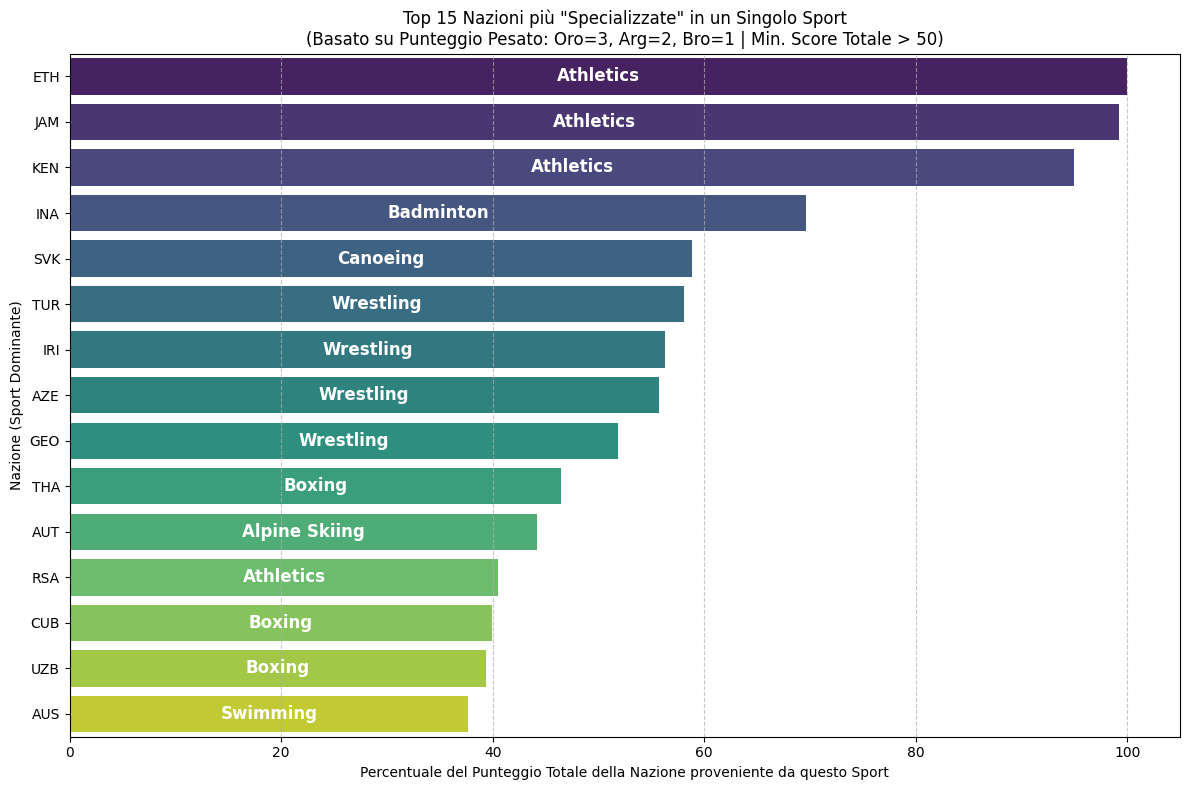

In [30]:
df_medals = df_moderno[
    (df_moderno['Medal_Gold'] == 1) |
    (df_moderno['Medal_Silver'] == 1) |
    (df_moderno['Medal_Bronze'] == 1)
].copy()

def get_medal(row):
    if row['Medal_Gold'] == 1:
        return 'Gold'
    elif row['Medal_Silver'] == 1:
        return 'Silver'
    elif row['Medal_Bronze'] == 1:
        return 'Bronze'
    else:
        return np.nan

df_medals['Medal'] = df_medals.apply(get_medal, axis=1)

# 2. Handle Team Sports vs Individual Sports
# A generic way to count "Medals for a Nation" rather than "Medals for Athletes" 
# is to drop duplicates on the specific event level for that country in that year.
# Example: 12 Basketball players from USA in 1992 get Gold. We want this to count as 1 Gold, not 12.
df_medals_unique = df_medals.drop_duplicates(subset=['Year', 'Season', 'Event', 'NOC', 'Medal'])

# 3. Assign Weights
weights = {'Gold': 3, 'Silver': 2, 'Bronze': 1}
df_medals_unique['Weight'] = df_medals_unique['Medal'].map(weights)

# 4. Calculate Total Weighted Score per Country
country_total_score = df_medals_unique.groupby('NOC')['Weight'].sum().reset_index(name='Total_Country_Score')

# 5. Calculate Weighted Score per Country per Sport
country_sport_score = df_medals_unique.groupby(['NOC', 'Sport'])['Weight'].sum().reset_index(name='Sport_Score')

# 6. Merge
merged = pd.merge(country_sport_score, country_total_score, on='NOC')

# 7. Calculate Percentage
merged['Specialization_Pct'] = (merged['Sport_Score'] / merged['Total_Country_Score']) * 100

# 8. Filter Data
# We need to remove "small" countries where 1 medal = 100%.
# Let's look at the distribution of Total_Country_Score to pick a cutoff.
# We'll start by getting the top sport for each country first.
max_sport_per_country = merged.loc[merged.groupby('NOC')['Specialization_Pct'].idxmax()]

# Now apply a threshold. Let's say a country needs at least a Total Score of 50 
# (equivalent to approx 16 Golds, or 25 Silvers, or 50 Bronzes over history).
# This ensures we are looking at established sporting nations.
threshold = 50
filtered_countries = max_sport_per_country[max_sport_per_country['Total_Country_Score'] >= threshold]

# 9. Get Top 15
top_15_specialized = filtered_countries.sort_values(by='Specialization_Pct', ascending=False).head(15)

# Display info for checking
print(top_15_specialized[['NOC', 'Sport', 'Specialization_Pct', 'Total_Country_Score']])

# 10. Plot
plt.figure(figsize=(12, 8))
top_15_specialized['Label'] = top_15_specialized['NOC'] 
sns.barplot(data=top_15_specialized, y='Label', x='Specialization_Pct', palette='viridis')
plt.title('Top 15 Nazioni più "Specializzate" in un Singolo Sport\n(Basato su Punteggio Pesato: Oro=3, Arg=2, Bro=1 | Min. Score Totale > 50)')
plt.xlabel('Percentuale del Punteggio Totale della Nazione proveniente da questo Sport')
plt.ylabel('Nazione (Sport Dominante)')
for i, (pct, sport) in enumerate(zip(top_15_specialized['Specialization_Pct'], top_15_specialized['Sport'])):
    plt.text(pct / 2, i, sport, color='white', ha='center', va='center', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 15 atleti che hanno trascinato la propria nazione

      NOC                                 Name                 Sport  \
5596  TUN  Mohamad Tlili ben Abdallah Gammoudi             Athletics   
3262  IRL     Michelle Marie Smith (-De Bruin)              Swimming   
1445  EGY          Karam Mohamed Gaber Ibrahim             Wrestling   
5585  TTO                    Ato Jabari Boldon             Athletics   
1209  CRO                       Janica Kosteli         Alpine Skiing   
1531  EST                      Andrus Veerpalu  Cross Country Skiing   
6     ALG                    Taoufik Makhloufi             Athletics   
5357  SVK                       Michal Martikn              Canoeing   
4127  MAR                   Hicham El Guerrouj             Athletics   
4104  LTU                    Virgilijus Alekna             Athletics   
3498  JAM                   Usain St. Leo Bolt             Athletics   
5238  SLO               Klementina "Tina" Maze         Alpine Skiing   
7247  UZB            Artur Borisovich Taymazov             Wrest

C:\Users\matte\AppData\Local\Temp\ipykernel_7528\3327894956.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_15_individual['Label'] =  top_15_individual['Name']
C:\Users\matte\AppData\Local\Temp\ipykernel_7528\3327894956.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_individual, y='Label', x='Carry_Pct', palette='plasma')


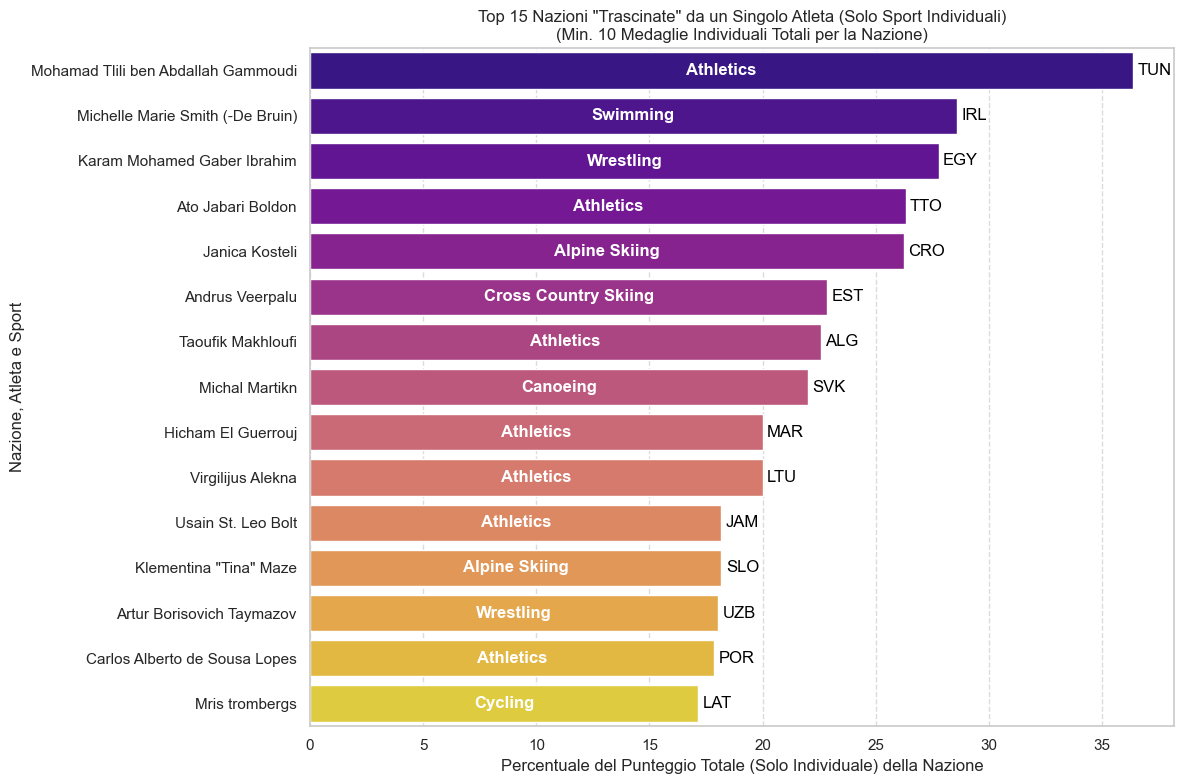

In [ ]:
df_medals = df_moderno[
    (df_moderno['Medal_Gold'] == 1) |
    (df_moderno['Medal_Silver'] == 1) |
    (df_moderno['Medal_Bronze'] == 1)
].copy()

def get_medal(row):
    if row['Medal_Gold'] == 1:
        return 'Gold'
    elif row['Medal_Silver'] == 1:
        return 'Silver'
    elif row['Medal_Bronze'] == 1:
        return 'Bronze'
    else:
        return np.nan

df_medals['Medal'] = df_medals.apply(get_medal, axis=1)# --- Step 1: Identificare e mantenere solo gli eventi individuali ---
# Definiamo un "Evento Individuale" come uno in cui solo 1 atleta di uno specifico NOC ha vinto una medaglia.
# Questo filtra automaticamente Staffette, Sport di Squadra (Calcio, Hockey), Doppi, Coppie, ecc.

# Contiamo gli atleti per ogni evento a medaglia
event_counts = df_medals.groupby(['Year', 'Season', 'Event', 'NOC', 'Medal'])['ID'].count().reset_index(name='Athlete_Count')

# Filtriamo per mantenere solo quelli con conteggio == 1
individual_events_keys = event_counts[event_counts['Athlete_Count'] == 1][['Year', 'Season', 'Event', 'NOC', 'Medal']]

# Uniamo nuovamente per ottenere i dettagli (Nomi, Sport, ecc.)
df_individual = pd.merge(df_medals, individual_events_keys, on=['Year', 'Season', 'Event', 'NOC', 'Medal'])

# Filtra il DataFrame per ciascuna stagione
df_summer = df_individual[df_individual['Season'] == 'Summer'].copy()
df_winter = df_individual[df_individual['Season'] == 'Winter'].copy()

# Doppio controllo: Rimuoviamo esplicitamente sport di squadra noti per sicurezza
team_sports_blacklist = [
    'Basketball', 'Football', 'Hockey', 'Volleyball', 'Handball', 'Water Polo', 
    'Baseball', 'Softball', 'Rugby', 'Rugby Sevens', 'Ice Hockey', 'Polo', 'Lacrosse', 'Tug-Of-War'
]
df_individual = df_individual[~df_individual['Sport'].isin(team_sports_blacklist)]

# --- Step 2: Calcolo dei Punteggi ---
# Assegnazione pesi: Oro=3, Argento=2, Bronzo=1
weights = {'Gold': 3, 'Silver': 2, 'Bronze': 1}
df_individual['Weight'] = df_individual['Medal'].map(weights)

# Statistiche Nazione (Denominatore)
# Poiché sono eventi singolo atleta, non serve rimuovere duplicati per il conteggio nazione
nation_stats = df_individual.groupby('NOC').agg(
    Nation_Total_Score=('Weight', 'sum'),
    Nation_Medal_Count=('Medal', 'count')
).reset_index()

# Filtro: La nazione deve avere almeno 10 medaglie individuali
filtered_nations = nation_stats[nation_stats['Nation_Medal_Count'] >= 10].copy()

# Statistiche Atleta (Numeratore)
athlete_stats = df_individual.groupby(['NOC', 'ID', 'Name', 'Sport']).agg(
    Athlete_Score=('Weight', 'sum'),
    Athlete_Medal_Count=('Medal', 'count')
).reset_index()

# --- Step 3: Unione e Ricerca del Top Atleta ---
merged = pd.merge(athlete_stats, filtered_nations, on='NOC')

# Calcolo percentuale di "Carry"
merged['Carry_Pct'] = (merged['Athlete_Score'] / merged['Nation_Total_Score']) * 100

# Ordiniamo e prendiamo il miglior atleta per nazione
merged_sorted = merged.sort_values(by='Carry_Pct', ascending=False)
top_athlete_per_nation = merged_sorted.drop_duplicates(subset=['NOC'])

# Top 15
top_15_individual = top_athlete_per_nation.head(15)

# Stampa di verifica
print(top_15_individual[['NOC', 'Name', 'Sport', 'Carry_Pct', 'Athlete_Score', 'Nation_Total_Score', 'Nation_Medal_Count']])

# --- Step 4: Grafico ---
plt.figure(figsize=(12, 8))
# Creazione etichetta per asse Y
top_15_individual['Label'] =  top_15_individual['Name']

sns.barplot(data=top_15_individual, y='Label', x='Carry_Pct', palette='plasma')

plt.title('Top 15 Nazioni "Trascinate" da un Singolo Atleta (Solo Sport Individuali)\n(Min. 10 Medaglie Individuali Totali per la Nazione)')
plt.xlabel('Percentuale del Punteggio Totale (Solo Individuale) della Nazione')
plt.ylabel('Nazione, Atleta e Sport')

for i, (carry_pct, sport) in enumerate(zip(top_15_individual['Carry_Pct'], top_15_individual['Sport'])):
    plt.text(carry_pct/2, i, sport, color='white', ha='center', va='center', fontsize=12, fontweight='bold')  # Testo al centro barra

# Annotazione: NAZIONE a destra della barra (NOC)
for i, (carry_pct, noc) in enumerate(zip(top_15_individual['Carry_Pct'], top_15_individual['NOC'])):
    plt.text(carry_pct + 0.2, i, noc, color='black', ha='left', va='center', fontsize=12)  # Testo a destra della barra

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()